<a href="https://colab.research.google.com/github/hmnaz213/native/blob/main/ICUMS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# I apologize for the previous delay.
# Please share your data or problem description here, and I'll do my best to solve it efficiently!

,No.,Trim Level,Year,Make,Model,HDV,Currency,Origin,HS Code,Exchange Rate,Receipt Date,Assessment Date,CIF NCY,Total Tax
0,1,S,2016,NISSAN,SENTRA,16780.0,USD,US,8703232000,5.8365,27/08/2021,25/08/2021,38740.24,13964.54
1,2,SV,2016,NISSAN,SENTRA,18550.0,USD,US,8703232000,5.8032,27/07/2021,26/07/2021,42145.74,15193.95
2,3,SV,2016,NISSAN,SENTRA,18550.0,USD,US,8703232000,5.7544,16/06/2021,09/06/2021,41791.33,15066.18
3,4,SR,2016,NISSAN,SENTRA,20410.0,USD,US,8703232000,5.7445,07/06/2021,04/06/2021,45491.79,16401.97
4,5,S,2016,NISSAN,SENTRA,16780.0,USD,US,8703232000,5.7499,08/06/2021,20/05/2021,38165.42,13757.35


STATISTICAL REPORT

Descriptive Statistics for Numeric Data:


,HDV,Exchange Rate,CIF NCY,Total Tax
count,97.000000,97.000000,97.000000,97.000000
mean,18382.783505,9.301666,87817.239175,33115.202165
std,1288.288385,3.365863,41727.326863,16792.199885
min,16780.000000,5.654900,38031.350000,13237.050000
25%,16780.000000,5.757100,44563.720000,15694.320000
50%,18550.000000,10.315200,103046.230000,38667.320000
75%,18550.000000,11.275600,114948.570000,44272.660000
max,22170.000000,16.358300,184468.060000,73776.350000



Value Counts for Categorical Data (Trim Level):


,count
Trim Level,
SV,43
S,31
SR,15
FE+ S,3
SL,2
S V,1
FE+S,1
N/A,1


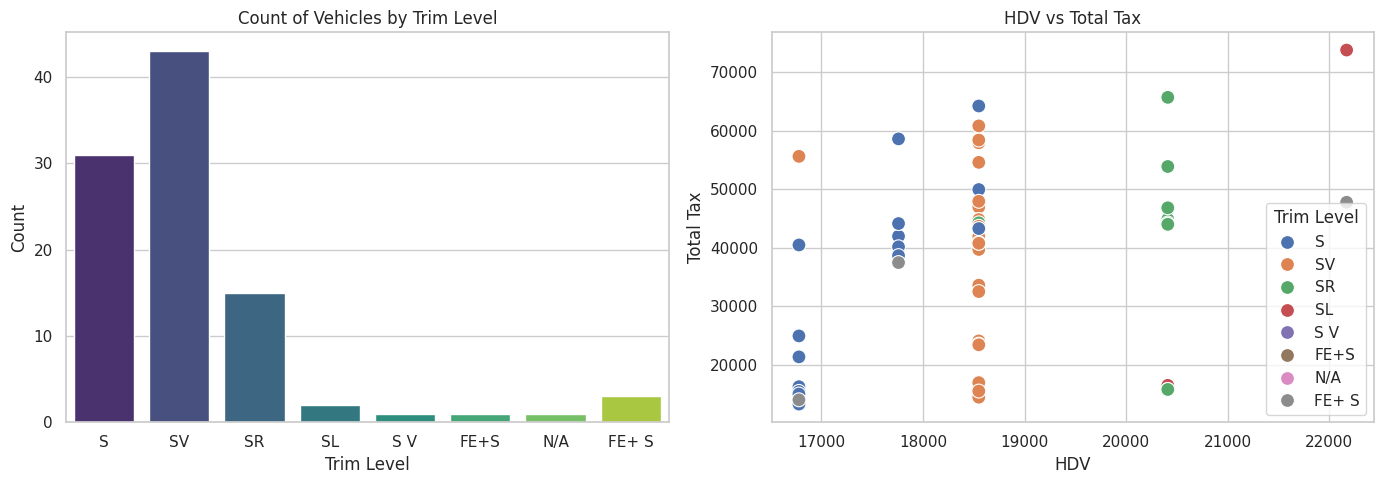

In [9]:
import pandas as pd
from google.colab import auth
import gspread
from google.auth import default
import matplotlib.pyplot as plt
import seaborn as sns

# Authenticate the user to access private Google Sheets
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# Open the sheet by its ID and read all values
sheet_id = "16YXeFyYPhTfZF0gfKj9N9hwT_W8hv-cw5wgRVnFvfWY"
worksheet = gc.open_by_key(sheet_id).sheet1
rows = worksheet.get_all_values()

# The data in the sheet is just raw text in the first column.
# Let's extract the strings and parse them using our custom logic.
lines = [row[0] for row in rows if row]

headers = ['No.', 'Trim Level', 'Year', 'Make', 'Model', 'HDV', 'Currency', 'Origin', 'HS Code', 'Exchange Rate', 'Receipt Date', 'Assessment Date', 'CIF NCY', 'Total Tax']

parsed_data = []
for line in lines:
    if line.startswith('raw_data =') or line.startswith('No.') or line.strip() == '"""':
        continue

    # remove trailing """ if any
    line = line.replace('"""', '').strip()
    parts = line.split()
    if len(parts) < 14:
        continue

    tail = parts[-9:]
    no = parts[0]
    middle = parts[1:-9]
    try:
        year_idx = next(i for i, val in enumerate(middle) if val.isdigit() and len(val) == 4)
        trim_level = " ".join(middle[:year_idx])
        year = middle[year_idx]
        make = middle[year_idx+1]
        model = " ".join(middle[year_idx+2:])
        parsed_row = [no, trim_level, year, make, model] + tail
        parsed_data.append(parsed_row)
    except StopIteration:
        continue

df = pd.DataFrame(parsed_data, columns=headers)

# Data Cleaning: Convert numeric columns from string to float
numeric_columns = ['HDV', 'Exchange Rate', 'CIF NCY', 'Total Tax']
for col in numeric_columns:
    df[col] = df[col].astype(str).str.replace(',', '').astype(float)

display(df.head())

# Generate Report
print("="*50)
print("STATISTICAL REPORT")
print("="*50)
print("\nDescriptive Statistics for Numeric Data:")
display(df.describe())

print("\nValue Counts for Categorical Data (Trim Level):")
display(df['Trim Level'].value_counts())

# Generate Plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Bar chart for Trim Levels
sns.countplot(data=df, x='Trim Level', hue='Trim Level', ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Count of Vehicles by Trim Level')
axes[0].set_ylabel('Count')

# Plot B: Scatter Plot of HDV vs Total Tax
sns.scatterplot(data=df, x='HDV', y='Total Tax', hue='Trim Level', s=100, ax=axes[1])
axes[1].set_title('HDV vs Total Tax')

plt.tight_layout()
plt.show()


Correlation Matrix:


,HDV,Exchange Rate,CIF NCY,Total Tax
HDV,1.000000,0.334351,0.448829,0.442519
Exchange Rate,0.334351,1.000000,0.985657,0.985616
CIF NCY,0.448829,0.985657,1.000000,0.998484
Total Tax,0.442519,0.985616,0.998484,1.000000


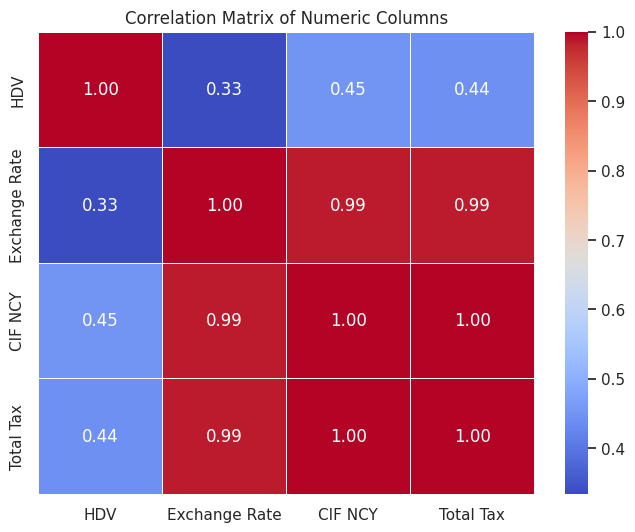

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the numeric columns for correlation
numeric_cols = ['HDV', 'Exchange Rate', 'CIF NCY', 'Total Tax']
corr_matrix = df[numeric_cols].corr()

print("Correlation Matrix:")
display(corr_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Columns')
plt.show()


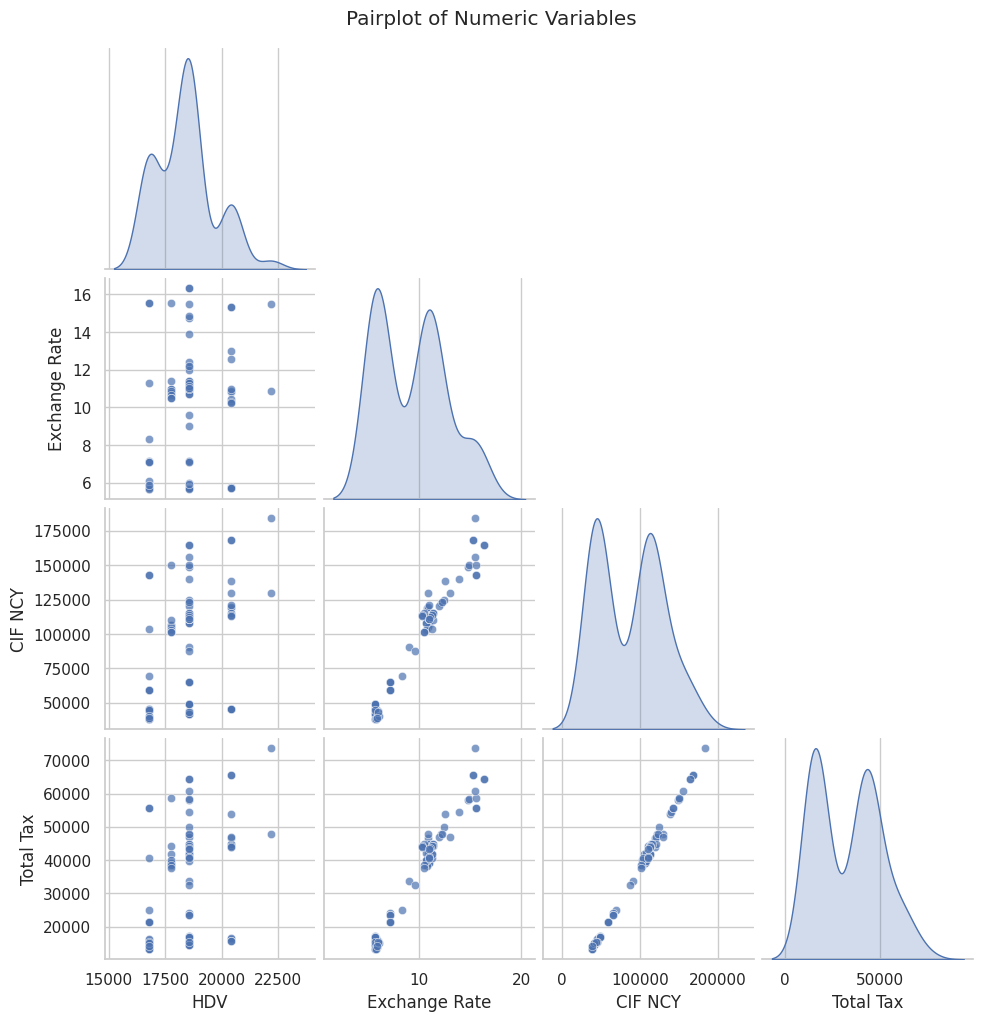

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pairplot for the numeric columns
sns.pairplot(df[numeric_cols], diag_kind='kde', corner=True, plot_kws={'alpha': 0.7})
plt.suptitle('Pairplot of Numeric Variables', y=1.02)
plt.show()


In [12]:
# Let's check if Total Tax is a fixed percentage of the CIF NCY value
df['Tax to CIF Ratio'] = df['Total Tax'] / df['CIF NCY']

# Display a few rows to see the raw numbers
display(df[['HDV', 'CIF NCY', 'Total Tax', 'Tax to CIF Ratio']].head())

# Check the statistical distribution of this ratio to see if it's constant
print("\nStatistics for the Tax to CIF Ratio:")
print(df['Tax to CIF Ratio'].describe())

# Also let's check if there's a formula for CIF NCY from HDV and Exchange Rate
df['Estimated CIF (HDV * Exch Rate)'] = df['HDV'] * df['Exchange Rate']
print("\nChecking if CIF NCY is derived directly from HDV and Exchange Rate...")
display(df[['HDV', 'Exchange Rate', 'CIF NCY', 'Estimated CIF (HDV * Exch Rate)']].head())

,HDV,CIF NCY,Total Tax,Tax to CIF Ratio
0,16780.0,38740.24,13964.54,0.360466
1,18550.0,42145.74,15193.95,0.360510
2,18550.0,41791.33,15066.18,0.360510
3,20410.0,45491.79,16401.97,0.360548
4,16780.0,38165.42,13757.35,0.360466



Statistics for the Tax to CIF Ratio:
count    97.000000
mean      0.370535
std       0.016526
min       0.348055
25%       0.360466
50%       0.368921
75%       0.389886
max       0.399941
Name: Tax to CIF Ratio, dtype: float64

Checking if CIF NCY is derived directly from HDV and Exchange Rate...


,HDV,Exchange Rate,CIF NCY,Estimated CIF (HDV * Exch Rate)
0,16780.0,5.8365,38740.24,97936.470
1,18550.0,5.8032,42145.74,107649.360
2,18550.0,5.7544,41791.33,106744.120
3,20410.0,5.7445,45491.79,117245.245
4,16780.0,5.7499,38165.42,96483.322


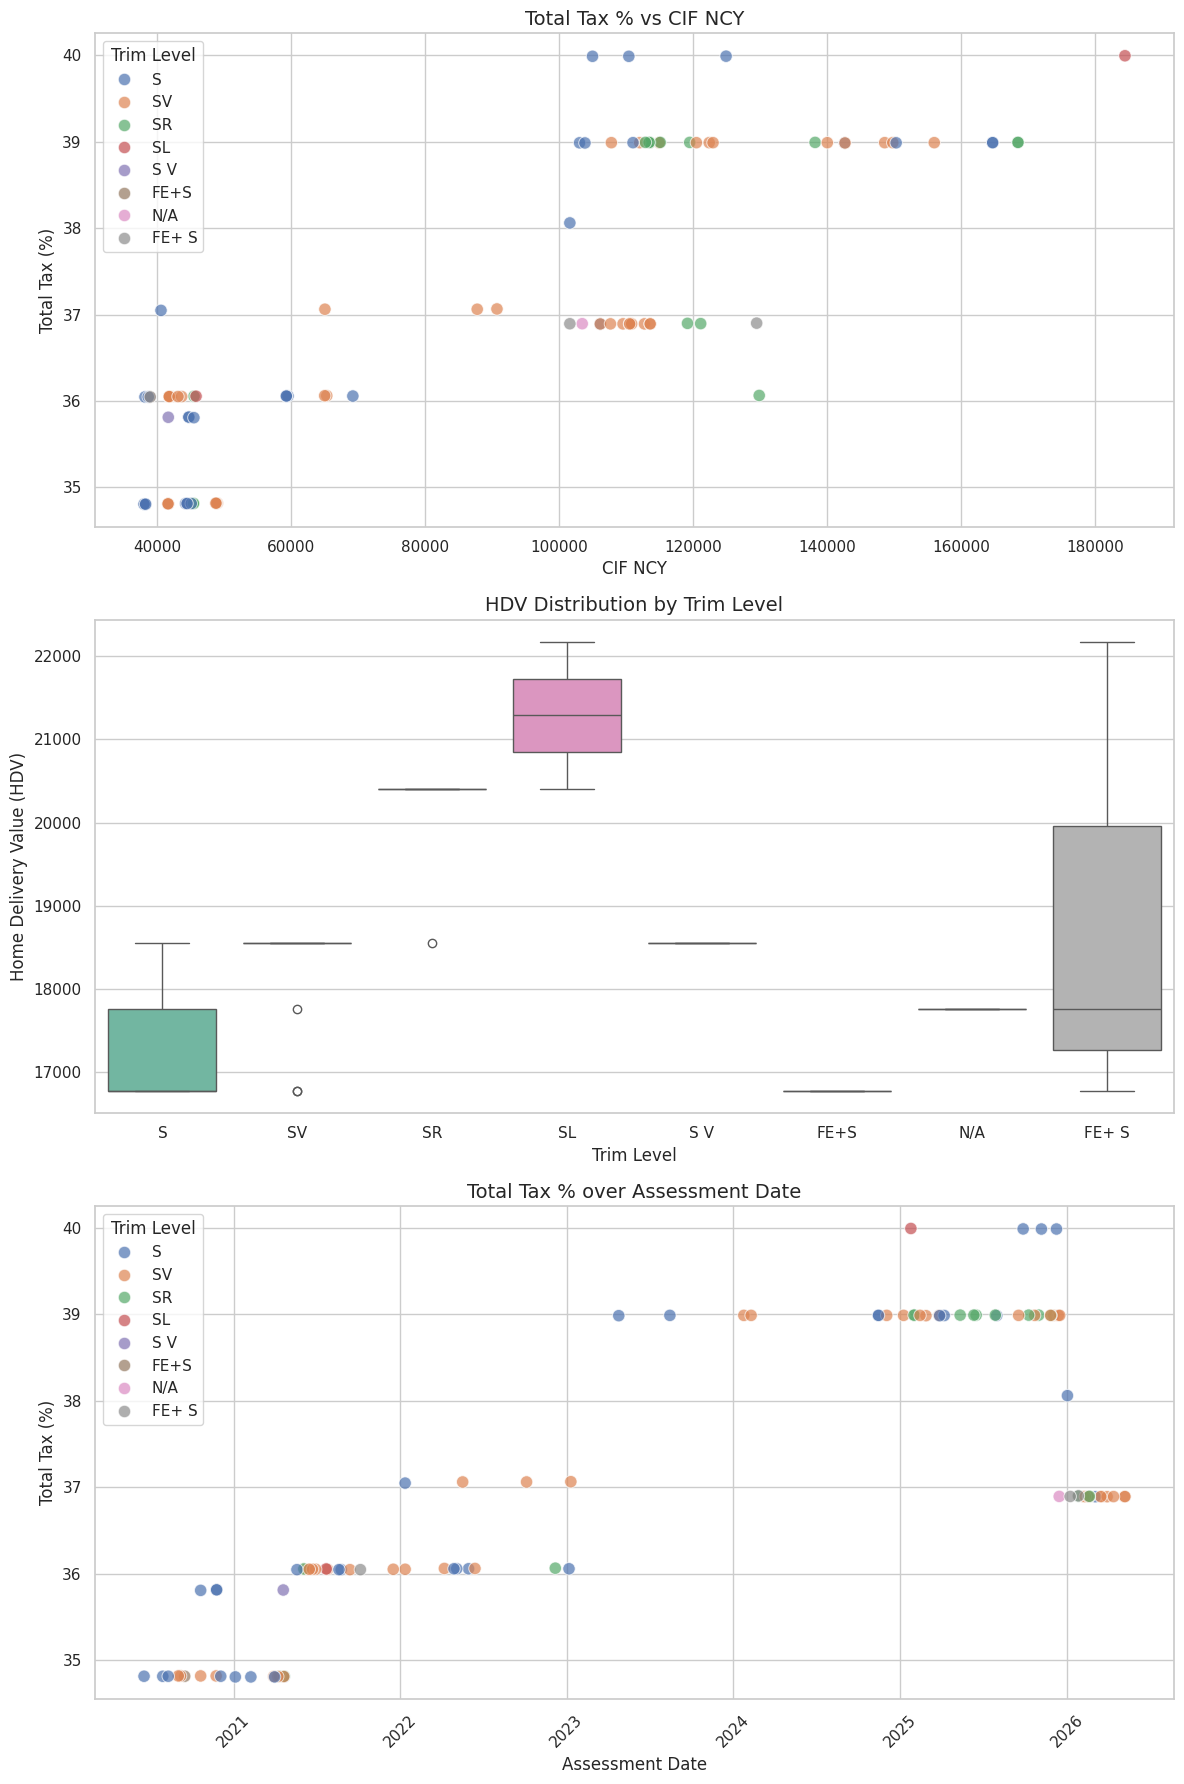

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare the data
# Convert the ratio to a clean percentage
df['Total Tax %'] = df['Tax to CIF Ratio'] * 100

# Convert 'Assessment Date' to actual datetime objects (format appears to be DD/MM/YYYY based on previous data)
df['Assessment Date'] = pd.to_datetime(df['Assessment Date'], format='%d/%m/%Y', errors='coerce')

# Set up the visualization grid (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
sns.set_theme(style="whitegrid")

# 1. Total Tax % against CIF NCY
sns.scatterplot(data=df, x='CIF NCY', y='Total Tax %', hue='Trim Level', s=80, alpha=0.7, ax=axes[0])
axes[0].set_title('Total Tax % vs CIF NCY', fontsize=14)
axes[0].set_ylabel('Total Tax (%)')

# 2. Trim Level against HDV
sns.boxplot(data=df, x='Trim Level', y='HDV', hue='Trim Level', legend=False, ax=axes[1], palette='Set2')
axes[1].set_title('HDV Distribution by Trim Level', fontsize=14)
axes[1].set_xlabel('Trim Level')
axes[1].set_ylabel('Home Delivery Value (HDV)')

# 3. Total Tax % against Assessment Date
sns.scatterplot(data=df, x='Assessment Date', y='Total Tax %', hue='Trim Level', s=80, alpha=0.7, ax=axes[2])
axes[2].set_title('Total Tax % over Assessment Date', fontsize=14)
axes[2].set_xlabel('Assessment Date')
axes[2].set_ylabel('Total Tax (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

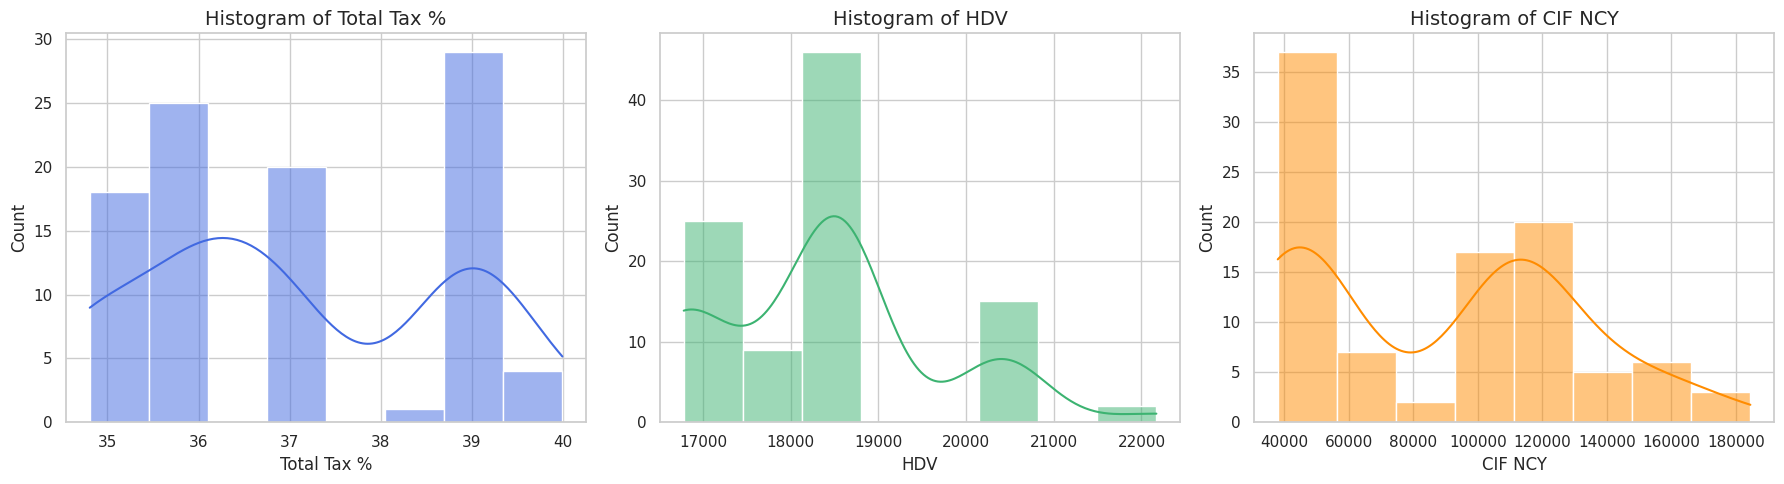

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the visualization grid for histograms (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# 1. Histogram of Total Tax %
sns.histplot(data=df, x='Total Tax %', kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Histogram of Total Tax %', fontsize=14)

# 2. Histogram of HDV
sns.histplot(data=df, x='HDV', kde=True, ax=axes[1], color='mediumseagreen')
axes[1].set_title('Histogram of HDV', fontsize=14)

# 3. Histogram of CIF NCY
sns.histplot(data=df, x='CIF NCY', kde=True, ax=axes[2], color='darkorange')
axes[2].set_title('Histogram of CIF NCY', fontsize=14)

plt.tight_layout()
plt.show()

In [16]:
# Calculate the mean Total Tax % for each Trim Level
mean_tax_by_trim = df.groupby('Trim Level')['Total Tax %'].mean().reset_index()

# Sort the results for better readability
mean_tax_by_trim = mean_tax_by_trim.sort_values(by='Total Tax %', ascending=False)

print("Mean Total Tax % by Trim Level:")
display(mean_tax_by_trim)

Mean Total Tax % by Trim Level:


,Trim Level,Total Tax %
5,SL,38.024461
6,SR,37.763949
7,SV,37.004116
2,N/A,36.893996
3,S,36.875799
0,FE+ S,36.613437
4,S V,35.811095
1,FE+S,34.813229


Cleaned Mean Total Tax % by Trim Level:


,Trim Level,Total Tax %
3,SL,38.024461
4,SR,37.763949
5,SV,36.977002
1,N/A,36.893996
2,S,36.875799
0,FE+S,36.163385


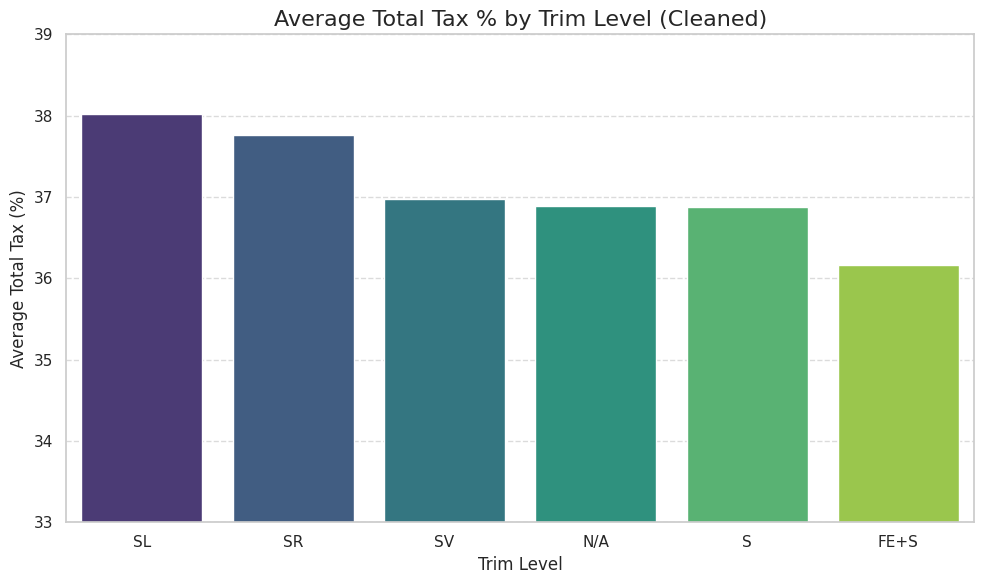

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean up the Trim Level inconsistencies
df['Trim Level'] = df['Trim Level'].replace({'S V': 'SV', 'FE+ S': 'FE+S'})

# Recalculate the mean Total Tax % for each cleaned Trim Level
mean_tax_by_trim_cleaned = df.groupby('Trim Level')['Total Tax %'].mean().reset_index()

# Sort the results for the plot
mean_tax_by_trim_cleaned = mean_tax_by_trim_cleaned.sort_values(by='Total Tax %', ascending=False)

print("Cleaned Mean Total Tax % by Trim Level:")
display(mean_tax_by_trim_cleaned)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=mean_tax_by_trim_cleaned, x='Trim Level', y='Total Tax %', hue='Trim Level', palette='viridis', legend=False)
plt.title('Average Total Tax % by Trim Level (Cleaned)', fontsize=16)
plt.xlabel('Trim Level', fontsize=12)
plt.ylabel('Average Total Tax (%)', fontsize=12)

# Set y-axis limit to highlight the differences better (since all are between 34% and 39%)
plt.ylim(33, 39)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

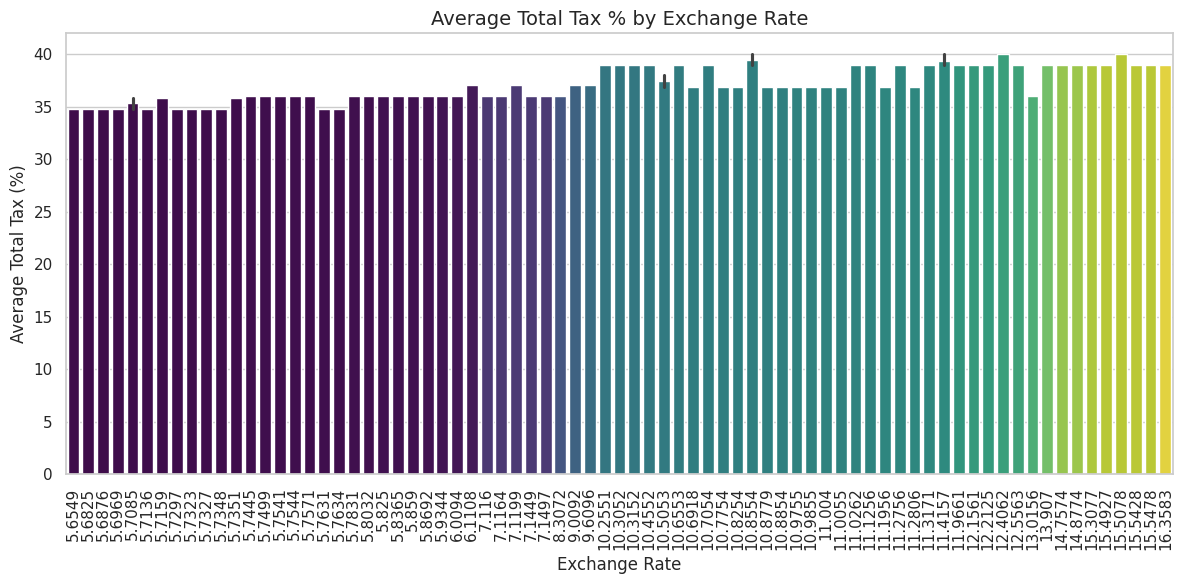

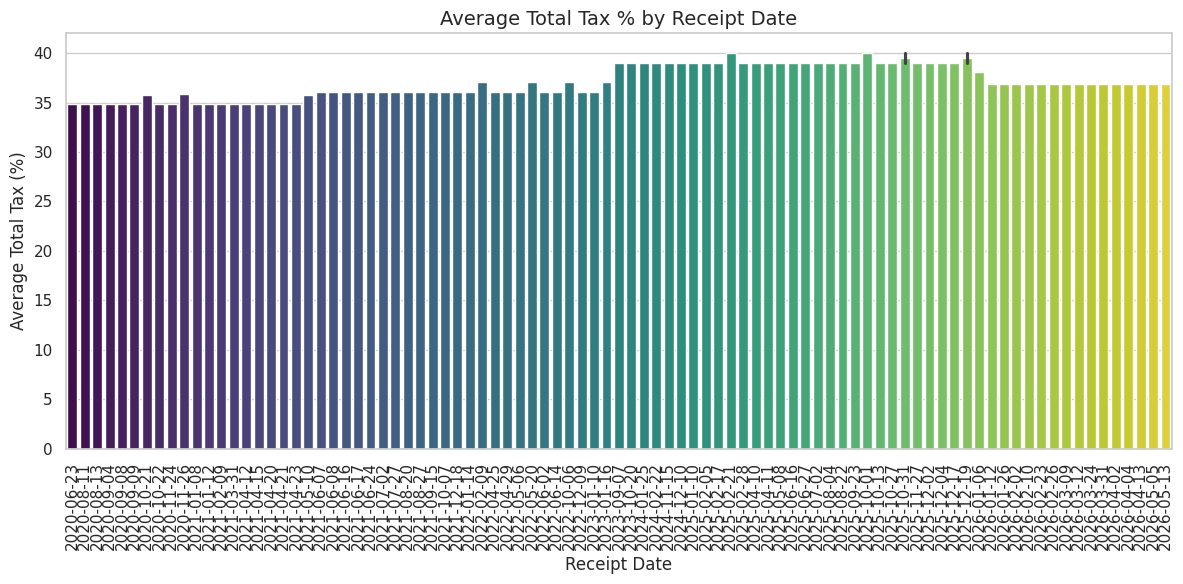

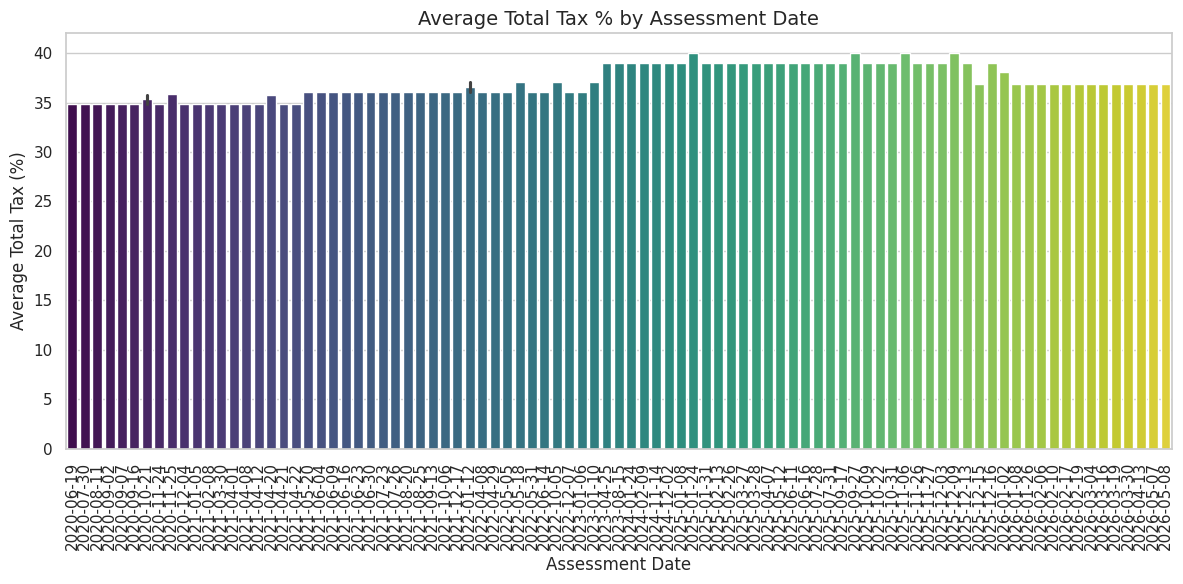

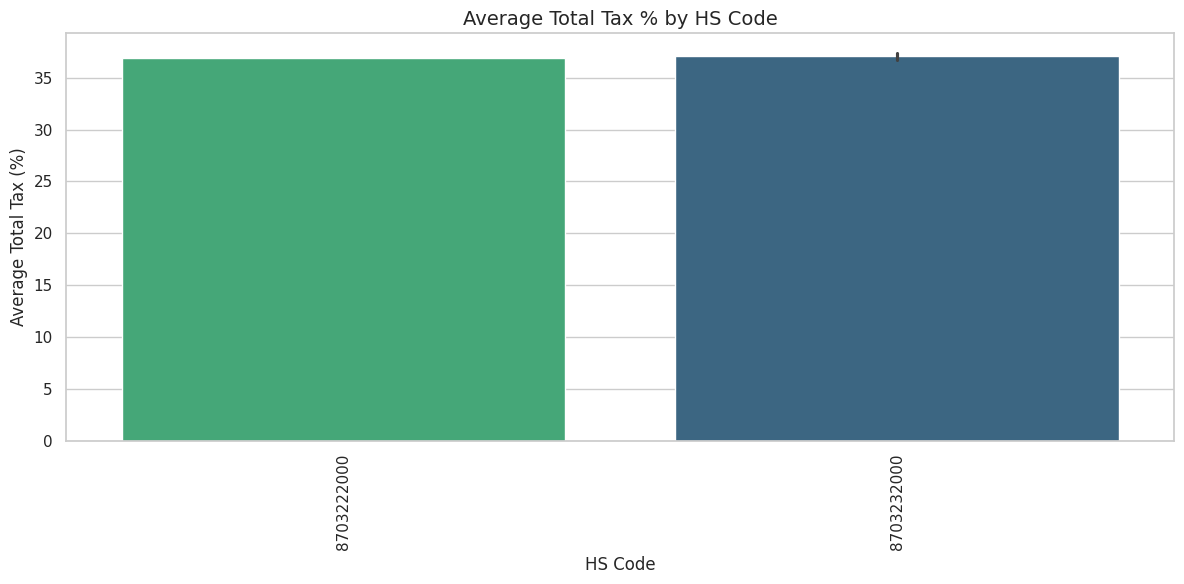

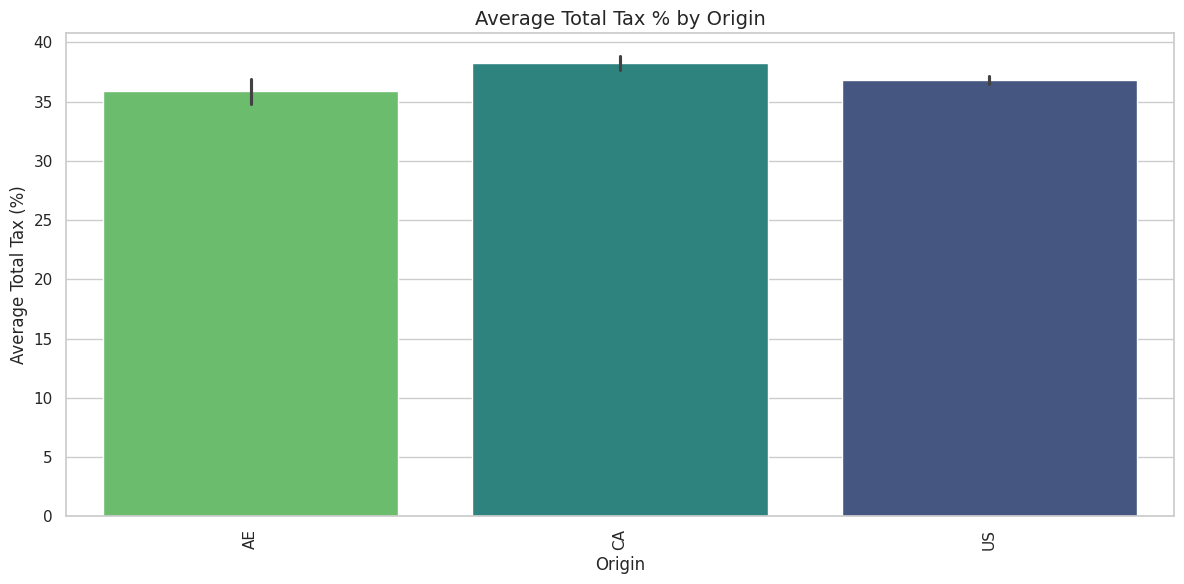

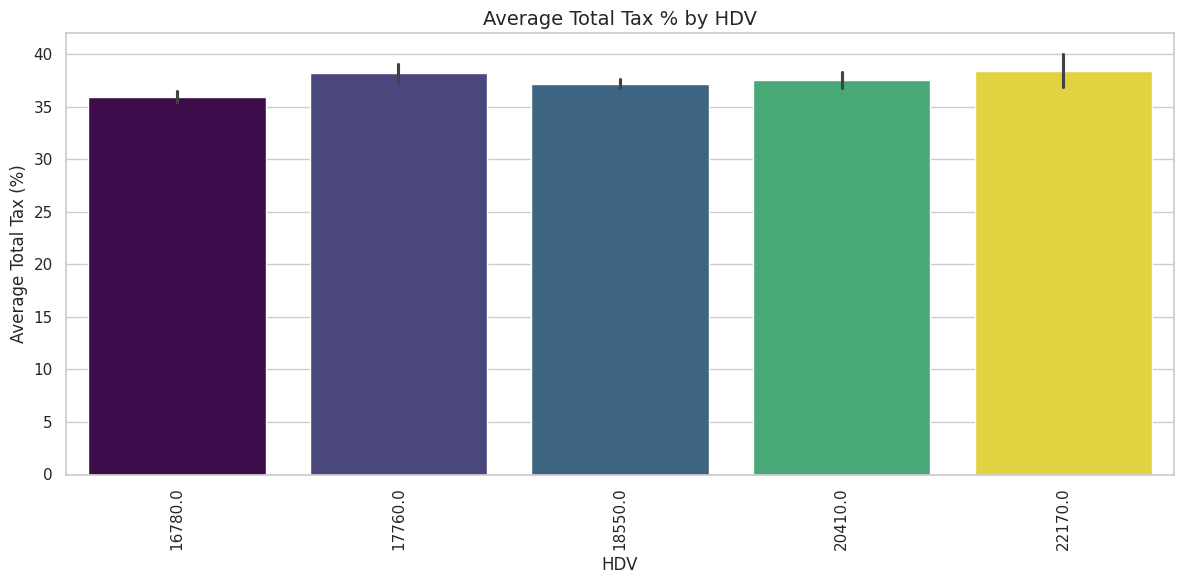

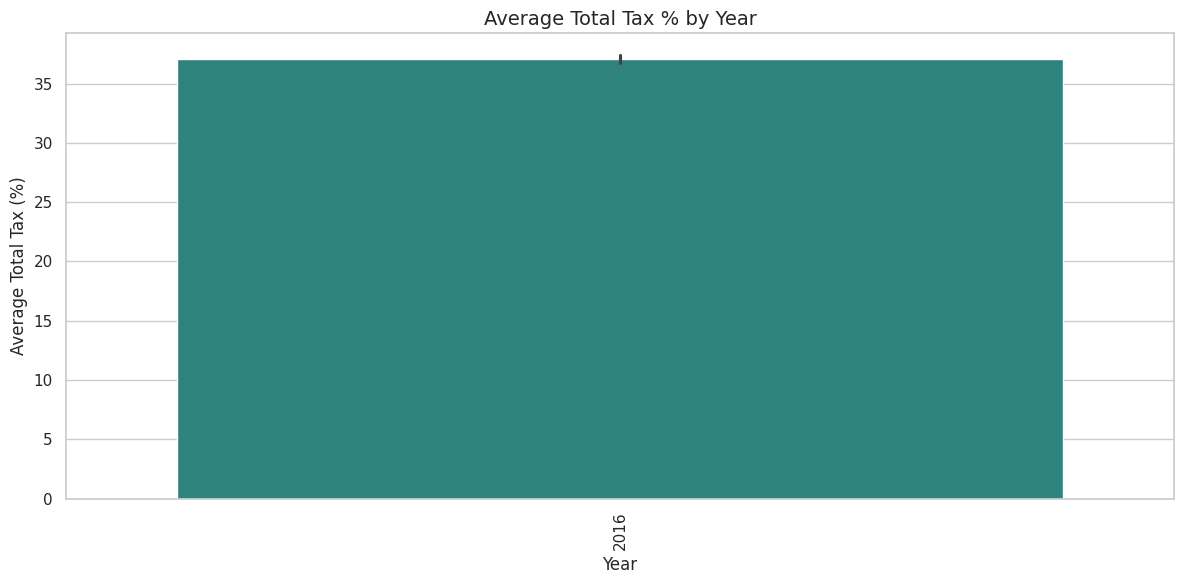

/tmp/ipykernel_5471/999631456.py:48: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


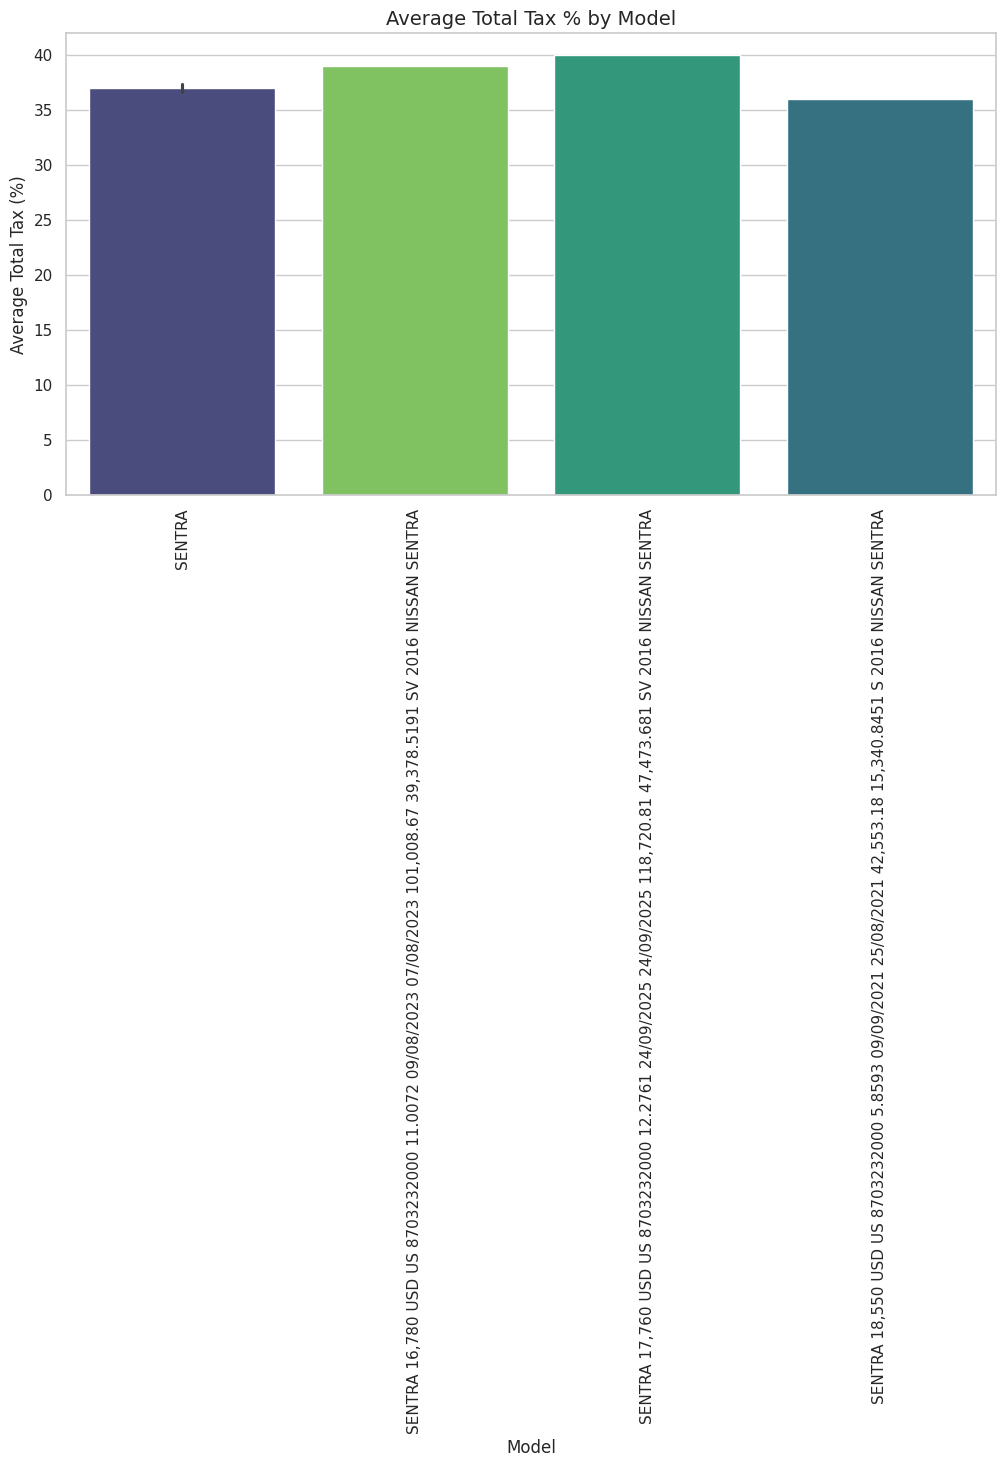

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure Date columns are datetime objects for proper plotting
df['Receipt Date'] = pd.to_datetime(df['Receipt Date'], format='%d/%m/%Y', errors='coerce')
df['Assessment Date'] = pd.to_datetime(df['Assessment Date'], format='%d/%m/%Y', errors='coerce')

sns.set_theme(style="whitegrid")

# Define the features to plot as bar charts
features_to_plot = [
    'Exchange Rate',
    'Receipt Date',
    'Assessment Date',
    'HS Code',
    'Origin',
    'HDV',
    'Year',
    'Model'
]

# Loop through and generate a separate figure for each feature
for feature in features_to_plot:
    plt.figure(figsize=(12, 6))

    plot_df = df.copy()

    if feature in ['Receipt Date', 'Assessment Date']:
        # Sort dates in ascending order and format them to string for clean x-axis labels
        plot_df = plot_df.sort_values(by=feature)
        plot_df[feature] = plot_df[feature].dt.strftime('%Y-%m-%d')
        order = plot_df[feature].dropna().unique() # Preserves the sorted order
    else:
        # Ensure ascending order for all other variables as well
        order = sorted(plot_df[feature].dropna().unique())

    # Using barplot with explicitly defined 'order'
    sns.barplot(data=plot_df, x=feature, y='Total Tax %', hue=feature, palette='viridis', legend=False, order=order)

    # Rotate x-axis labels 90 degrees because continuous data will have many bars
    plt.xticks(rotation=90)

    plt.title(f'Average Total Tax % by {feature}', fontsize=14)
    plt.ylabel('Average Total Tax (%)')
    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

In [23]:
import pandas as pd
import numpy as np

# 1. Models by HS Code
print("--- Models by HS Code ---")
hs_code_models = df.groupby('HS Code')['Model'].unique().reset_index()
display(hs_code_models)

# 2. Models by Origin
print("\n--- Models by Origin ---")
origin_models = df.groupby('Origin')['Model'].unique().reset_index()
display(origin_models)

# 3. Models by HDV
print("\n--- Models by HDV ---")
hdv_models = df.groupby('HDV')['Model'].unique().reset_index()
display(hdv_models)

# 4. Overlap across HS Code, Origin, and HDV
print("\n--- Overlap across HS Code, Origin, and HDV ---")
overlap_df = df.groupby(['HS Code', 'Origin', 'HDV']).agg(
    Unique_Models=('Model', lambda x: list(x.unique())),
    Count=('Model', 'count')
).reset_index()

# Calculate percentage
overlap_df['Percentage (%)'] = (overlap_df['Count'] / len(df)) * 100
overlap_df = overlap_df.sort_values(by='Percentage (%)', ascending=False)
display(overlap_df)

--- Models by HS Code ---


,HS Code,Model
0,8703222000,[SENTRA]
1,8703232000,"[SENTRA, SENTRA 18,550 USD US 8703232000 5.859..."



--- Models by Origin ---


,Origin,Model
0,AE,[SENTRA]
1,CA,"[SENTRA, SENTRA 17,760 USD US 8703232000 12.27..."
2,US,"[SENTRA, SENTRA 18,550 USD US 8703232000 5.859..."



--- Models by HDV ---


,HDV,Model
0,16780.0,"[SENTRA, SENTRA 18,550 USD US 8703232000 5.859..."
1,17760.0,[SENTRA]
2,18550.0,"[SENTRA, SENTRA 17,760 USD US 8703232000 12.27..."
3,20410.0,[SENTRA]
4,22170.0,[SENTRA]



--- Overlap across HS Code, Origin, and HDV ---


,HS Code,Origin,HDV,Unique_Models,Count,Percentage (%)
9,8703232000,US,18550.0,"[SENTRA, SENTRA 16,780 USD US 8703232000 11.00...",43,44.329897
7,8703232000,US,16780.0,"[SENTRA, SENTRA 18,550 USD US 8703232000 5.859...",22,22.680412
5,8703232000,CA,20410.0,[SENTRA],9,9.278351
8,8703232000,US,17760.0,[SENTRA],6,6.185567
10,8703232000,US,20410.0,[SENTRA],6,6.185567
4,8703232000,CA,18550.0,"[SENTRA, SENTRA 17,760 USD US 8703232000 12.27...",3,3.092784
2,8703232000,CA,16780.0,[SENTRA],2,2.061856
3,8703232000,CA,17760.0,[SENTRA],2,2.061856
0,8703222000,AE,17760.0,[SENTRA],1,1.030928
1,8703232000,AE,16780.0,[SENTRA],1,1.030928


In [24]:
# 5. Correlation between Total Tax, Total Tax %, and Exchange Rate across the years
print("\n--- Correlation across Assessment Years ---")
# Extract year from Assessment Date
df['Assessment Year'] = df['Assessment Date'].dt.year

# Sort years in ascending order
years = sorted(df['Assessment Year'].dropna().unique())

for year in years:
    year_df = df[df['Assessment Year'] == year]
    if len(year_df) > 1:
        corr = year_df[['Total Tax', 'Total Tax %', 'Exchange Rate']].corr()
        print(f"\nCorrelation for Year {int(year)} (N={len(year_df)}):")
        display(corr)
    else:
        print(f"\nNot enough data to calculate correlation for Year {int(year)} (N={len(year_df)})")


--- Correlation across Assessment Years ---

Correlation for Year 2020 (N=12):


,Total Tax,Total Tax %,Exchange Rate
Total Tax,1.000000,-0.049745,0.171089
Total Tax %,-0.049745,1.000000,0.258014
Exchange Rate,0.171089,0.258014,1.000000



Correlation for Year 2021 (N=23):


,Total Tax,Total Tax %,Exchange Rate
Total Tax,1.000000,0.334234,-0.013249
Total Tax %,0.334234,1.000000,0.541664
Exchange Rate,-0.013249,0.541664,1.000000



Correlation for Year 2022 (N=10):


...

,Total Tax,Total Tax %,Exchange Rate
Total Tax,1.000000,-0.676827,1.000000
Total Tax %,-0.676827,1.000000,-0.676828
Exchange Rate,1.000000,-0.676828,1.000000



Correlation for Year 2025 (N=27):


,Total Tax,Total Tax %,Exchange Rate
Total Tax,1.000000,0.261969,0.905862
Total Tax %,0.261969,1.000000,0.125735
Exchange Rate,0.905862,0.125735,1.000000



Correlation for Year 2026 (N=16):


,Total Tax,Total Tax %,Exchange Rate
Total Tax,1.000000,-0.262784,0.353755
Total Tax %,-0.262784,1.000000,-0.505997
Exchange Rate,0.353755,-0.505997,1.000000


In [25]:
# Clean the jammed 'Model' column by keeping only the first word (the actual model name)
df['Model'] = df['Model'].apply(lambda x: x.split()[0] if isinstance(x, str) else x)

# Re-run the overlap analysis with the cleaned data
print("--- Cleaned Overlap across HS Code, Origin, and HDV ---")
overlap_df_cleaned = df.groupby(['HS Code', 'Origin', 'HDV']).agg(
    Unique_Models=('Model', lambda x: list(x.unique())),
    Count=('Model', 'count')
).reset_index()

# Calculate percentage
overlap_df_cleaned['Percentage (%)'] = (overlap_df_cleaned['Count'] / len(df)) * 100
overlap_df_cleaned = overlap_df_cleaned.sort_values(by='Percentage (%)', ascending=False)
display(overlap_df_cleaned)

--- Cleaned Overlap across HS Code, Origin, and HDV ---


,HS Code,Origin,HDV,Unique_Models,Count,Percentage (%)
9,8703232000,US,18550.0,[SENTRA],43,44.329897
7,8703232000,US,16780.0,[SENTRA],22,22.680412
5,8703232000,CA,20410.0,[SENTRA],9,9.278351
8,8703232000,US,17760.0,[SENTRA],6,6.185567
10,8703232000,US,20410.0,[SENTRA],6,6.185567
4,8703232000,CA,18550.0,[SENTRA],3,3.092784
2,8703232000,CA,16780.0,[SENTRA],2,2.061856
3,8703232000,CA,17760.0,[SENTRA],2,2.061856
0,8703222000,AE,17760.0,[SENTRA],1,1.030928
1,8703232000,AE,16780.0,[SENTRA],1,1.030928


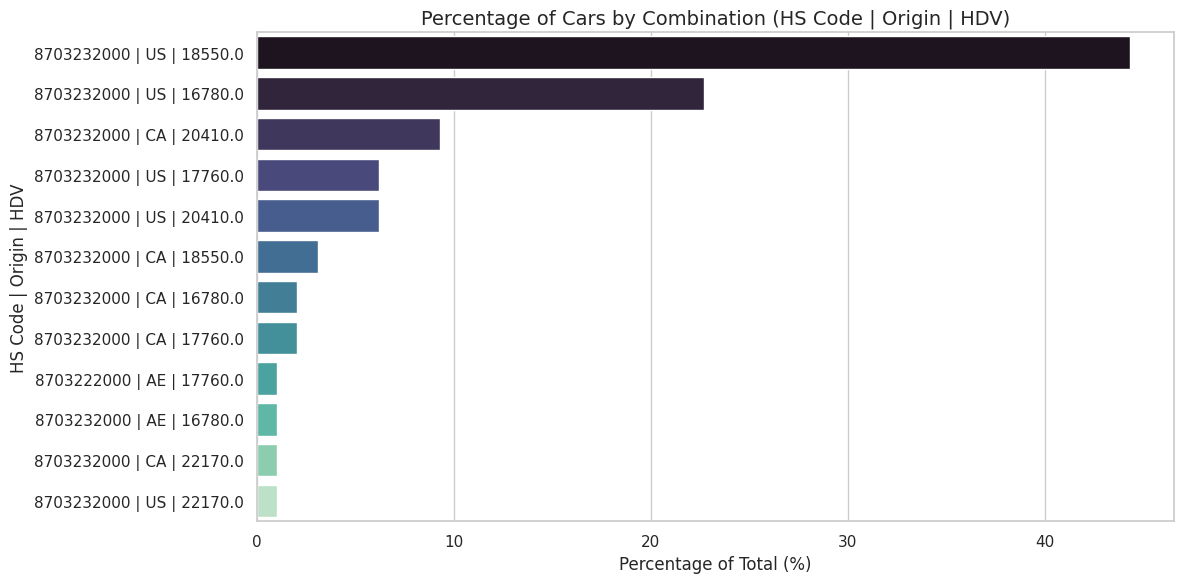

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Visualize Overlap Percentages
plt.figure(figsize=(12, 6))

# Create a combined label for the overlapping groups for better readability
overlap_df_cleaned['Group'] = overlap_df_cleaned['HS Code'].astype(str) + ' | ' + overlap_df_cleaned['Origin'] + ' | ' + overlap_df_cleaned['HDV'].astype(str)

# Bar plot for the combinations
sns.barplot(data=overlap_df_cleaned, x='Percentage (%)', y='Group', palette='mako', hue='Group', legend=False)
plt.title('Percentage of Cars by Combination (HS Code | Origin | HDV)', fontsize=14)
plt.xlabel('Percentage of Total (%)')
plt.ylabel('HS Code | Origin | HDV')

plt.tight_layout()
plt.show()

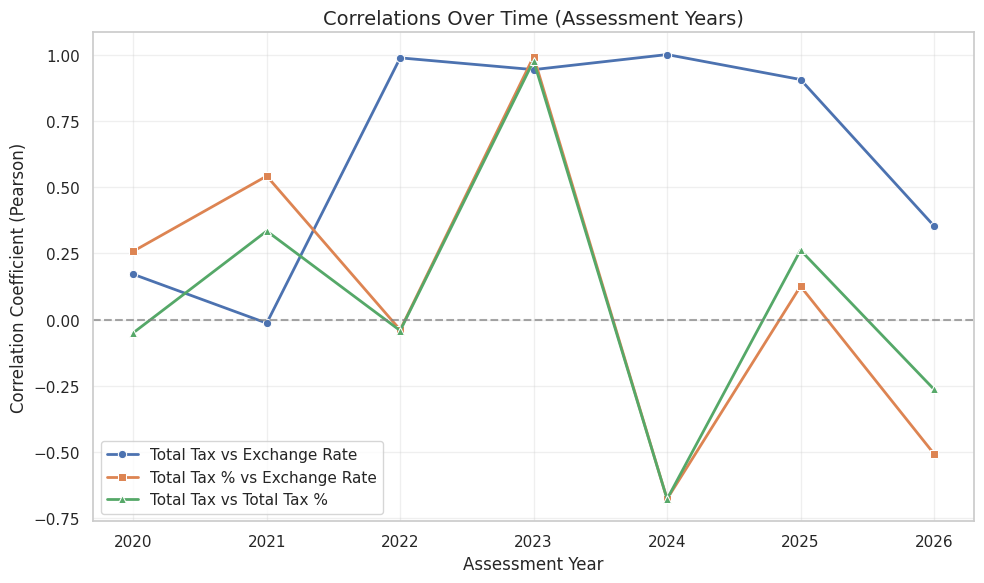

In [27]:
# 2. Visualize Correlations across Assessment Years
years = sorted(df['Assessment Year'].dropna().unique())
corr_records = []

# Collect the correlation metrics for each year
for year in years:
    year_df = df[df['Assessment Year'] == year]
    if len(year_df) > 1:
        corr = year_df[['Total Tax', 'Total Tax %', 'Exchange Rate']].corr()
        corr_records.append({
            'Year': year,
            'Tax vs Exch Rate': corr.loc['Total Tax', 'Exchange Rate'],
            'Tax % vs Exch Rate': corr.loc['Total Tax %', 'Exchange Rate'],
            'Tax vs Tax %': corr.loc['Total Tax', 'Total Tax %']
        })

corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(10, 6))
# Plot each correlation relationship over time
sns.lineplot(data=corr_df, x='Year', y='Tax vs Exch Rate', marker='o', label='Total Tax vs Exchange Rate', linewidth=2)
sns.lineplot(data=corr_df, x='Year', y='Tax % vs Exch Rate', marker='s', label='Total Tax % vs Exchange Rate', linewidth=2)
sns.lineplot(data=corr_df, x='Year', y='Tax vs Tax %', marker='^', label='Total Tax vs Total Tax %', linewidth=2)

# Add a baseline at 0 (no correlation)
plt.axhline(0, color='gray', linestyle='--', alpha=0.7)

plt.title('Correlations Over Time (Assessment Years)', fontsize=14)
plt.xlabel('Assessment Year')
plt.ylabel('Correlation Coefficient (Pearson)')
plt.xticks(corr_df['Year'])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== Feature Importance for Total Tax % ===


,Importance Score
Assessment Year,0.499373
CIF NCY,0.293939
Exchange Rate,0.186197
Trim Level,0.007580
HDV,0.005078
Origin,0.005012
HS Code,0.002821


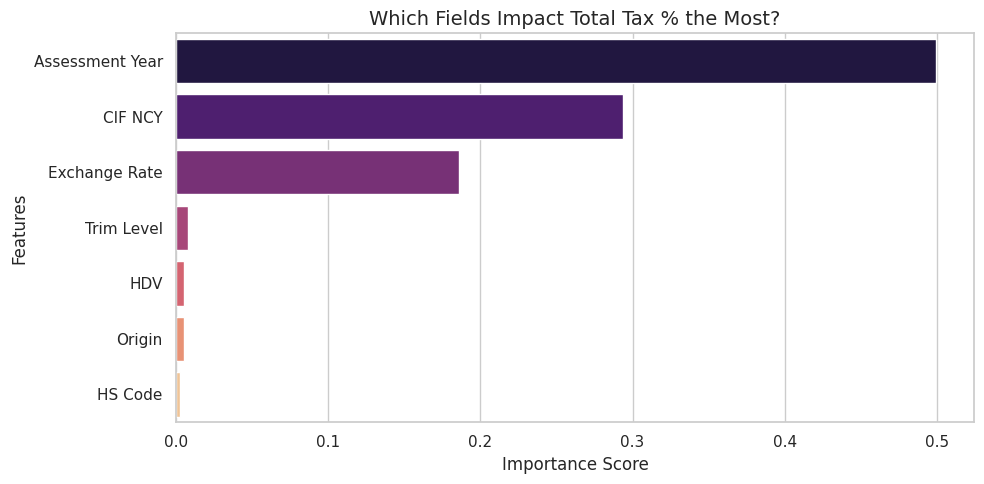

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# 1. Which fields impact Total Tax % the most?
# We use a Random Forest to calculate feature importances
features = ['Trim Level', 'HDV', 'Origin', 'HS Code', 'Exchange Rate', 'CIF NCY', 'Assessment Year']

# Prepare data by dropping missing values and encoding categoricals
rf_df = df.dropna(subset=features + ['Total Tax %']).copy()

le = LabelEncoder()
cat_cols = ['Trim Level', 'Origin', 'HS Code']
for col in cat_cols:
    rf_df[col] = le.fit_transform(rf_df[col].astype(str))

X = rf_df[features]
y = rf_df['Total Tax %']

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importances and sort them
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

print("=== Feature Importance for Total Tax % ===")
display(importances.to_frame('Importance Score'))

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='magma', legend=False)
plt.title('Which Fields Impact Total Tax % the Most?', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

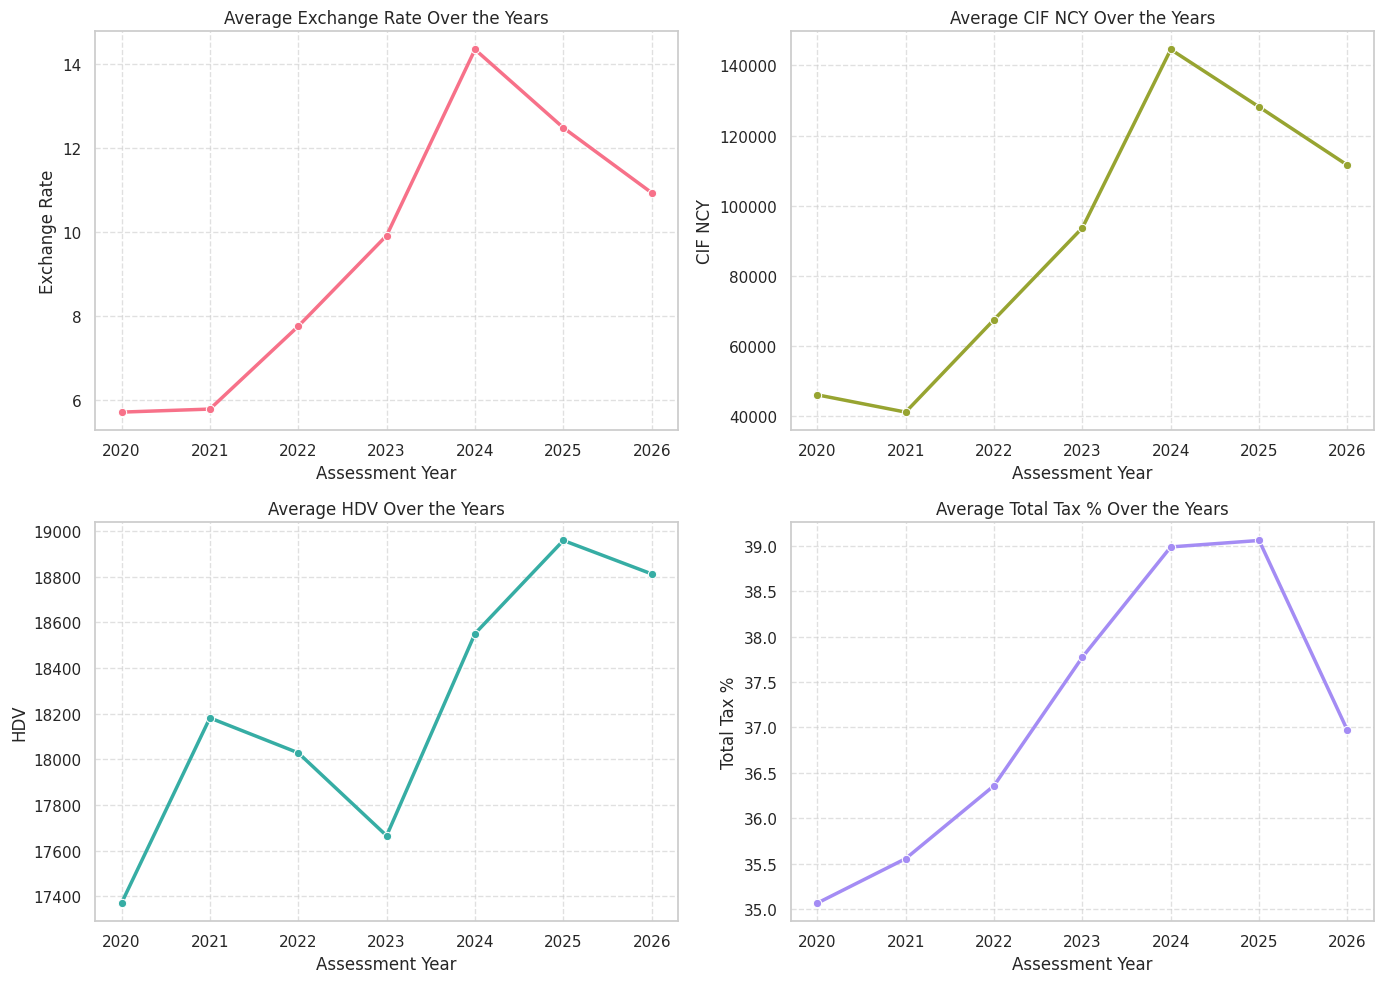

In [29]:
# 2. How have the top numerical fields moved over the years?
top_numeric_features = ['Exchange Rate', 'CIF NCY', 'HDV', 'Total Tax %']

# Group by Assessment Year
yearly_trends = df.groupby('Assessment Year')[top_numeric_features].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = sns.color_palette("husl", len(top_numeric_features))

for i, col in enumerate(top_numeric_features):
    sns.lineplot(data=yearly_trends, x='Assessment Year', y=col, marker='o', ax=axes[i], color=colors[i], linewidth=2.5)
    axes[i].set_title(f'Average {col} Over the Years', fontsize=12)
    axes[i].set_xticks(yearly_trends['Assessment Year'].dropna().unique())
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

=== Cars (Count) under various HS Codes ===


,HS Code,Car Count
1,8703232000,96
0,8703222000,1



=== Cars (Count) under various HDVs ===


,HDV,Car Count
2,18550.0,46
0,16780.0,25
3,20410.0,15
1,17760.0,9
4,22170.0,2


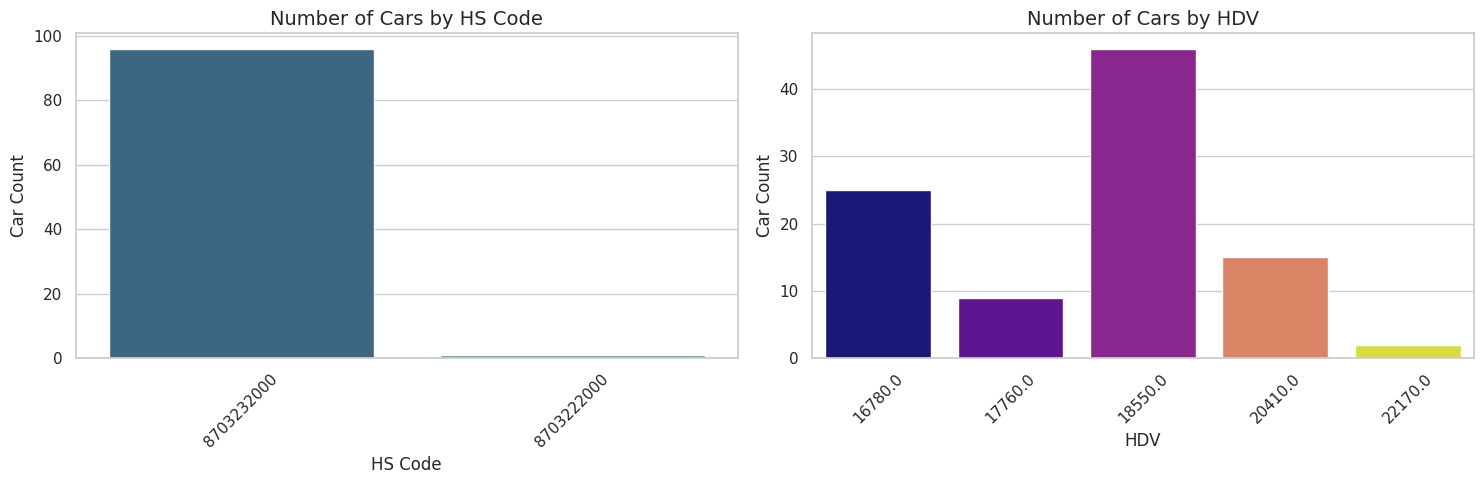

In [32]:
# 3. Cars under the various HS codes
print("=== Cars (Count) under various HS Codes ===")
hs_counts = df.groupby('HS Code').size().reset_index(name='Car Count').sort_values(by='Car Count', ascending=False)
display(hs_counts)

# 4. Cars under the various HDVs
print("\n=== Cars (Count) under various HDVs ===")
hdv_counts = df.groupby('HDV').size().reset_index(name='Car Count').sort_values(by='Car Count', ascending=False)
display(hdv_counts)

# Visualize the distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=hs_counts, x='HS Code', y='Car Count', hue='HS Code', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Number of Cars by HS Code', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=hdv_counts, x='HDV', y='Car Count', hue='HDV', palette='plasma', legend=False, ax=axes[1])
axes[1].set_title('Number of Cars by HDV', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

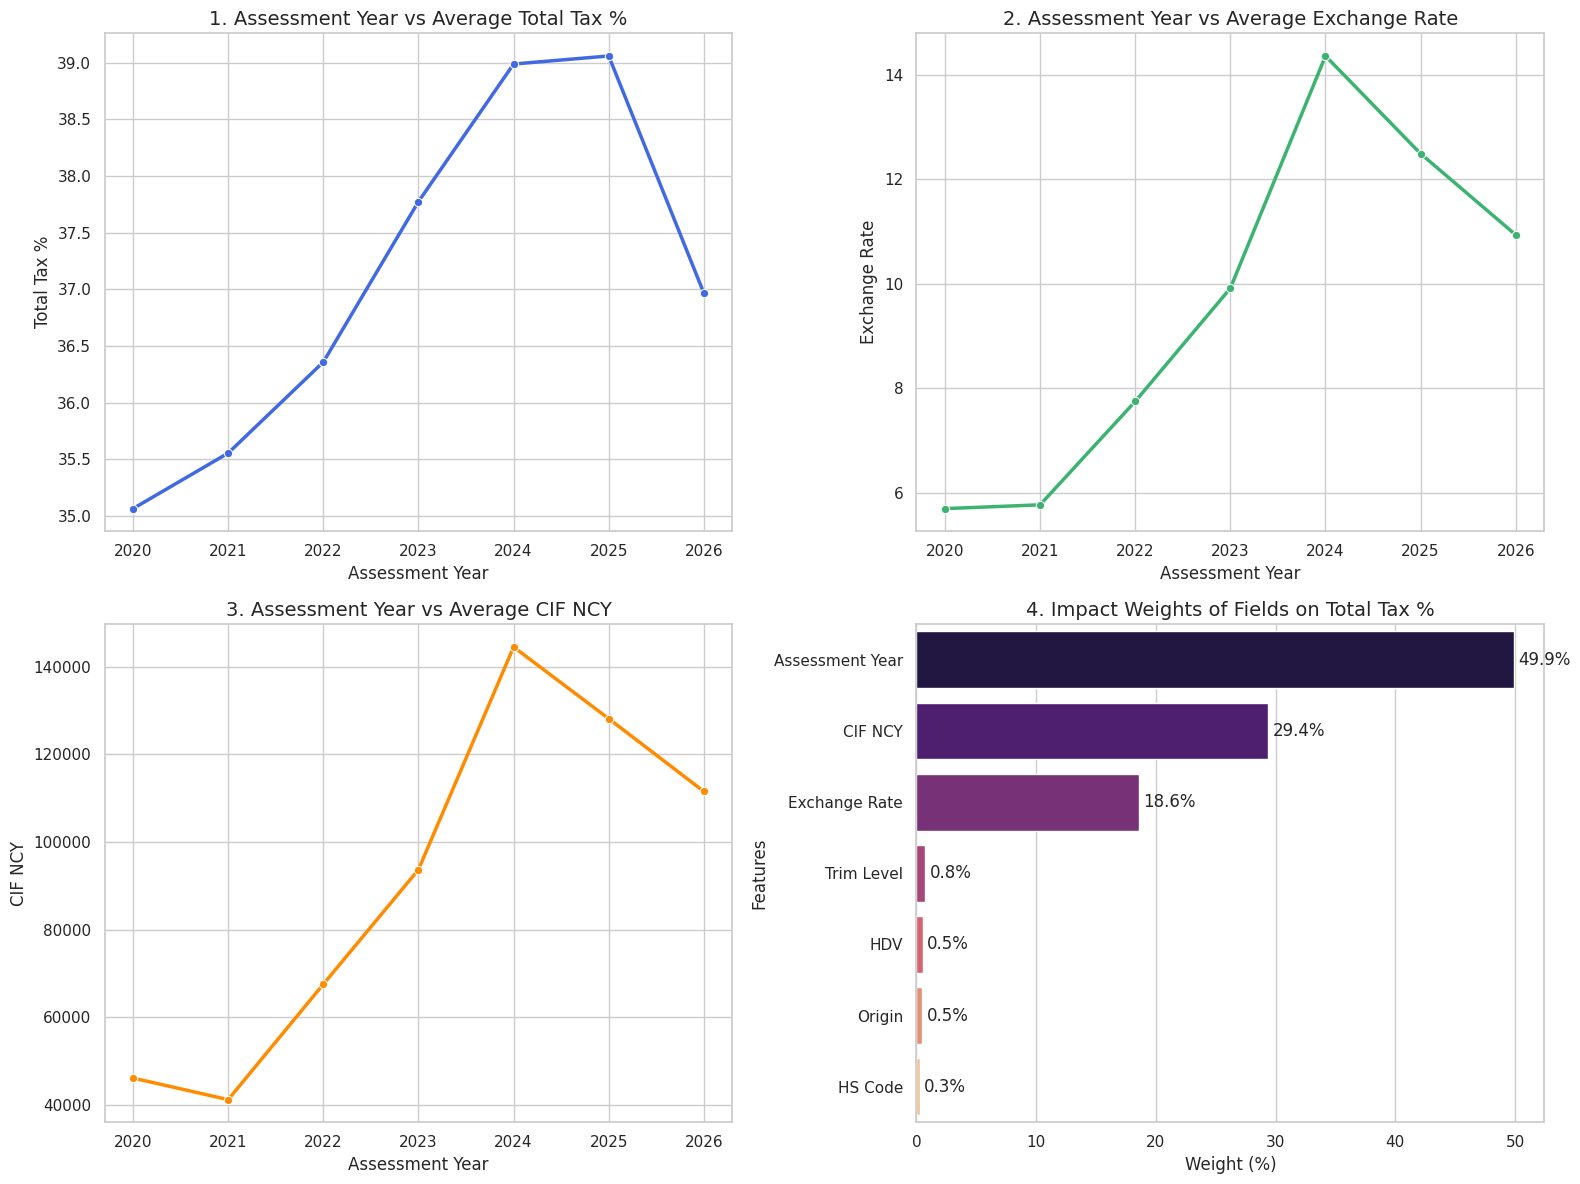

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure data is grouped and sorted by Assessment Year
yearly_metrics = df.groupby('Assessment Year')[['Total Tax %', 'Exchange Rate', 'CIF NCY']].mean().reset_index()
yearly_metrics = yearly_metrics.sort_values('Assessment Year')

# Set up the 2x2 visualization grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# 1. Assessment Year vs Total Tax %
sns.lineplot(data=yearly_metrics, x='Assessment Year', y='Total Tax %', marker='o', linewidth=2.5, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title('1. Assessment Year vs Average Total Tax %', fontsize=14)
axes[0, 0].set_xticks(yearly_metrics['Assessment Year'])

# 2. Assessment Year vs Exchange Rate
sns.lineplot(data=yearly_metrics, x='Assessment Year', y='Exchange Rate', marker='o', linewidth=2.5, ax=axes[0, 1], color='mediumseagreen')
axes[0, 1].set_title('2. Assessment Year vs Average Exchange Rate', fontsize=14)
axes[0, 1].set_xticks(yearly_metrics['Assessment Year'])

# 3. Assessment Year vs CIF NCY
sns.lineplot(data=yearly_metrics, x='Assessment Year', y='CIF NCY', marker='o', linewidth=2.5, ax=axes[1, 0], color='darkorange')
axes[1, 0].set_title('3. Assessment Year vs Average CIF NCY', fontsize=14)
axes[1, 0].set_xticks(yearly_metrics['Assessment Year'])

# 4. Impact Weights (%) of Fields
# Convert the importances calculated previously into percentages
weights_pct = (importances * 100).round(2)

sns.barplot(x=weights_pct.values, y=weights_pct.index, hue=weights_pct.index, palette='magma', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('4. Impact Weights of Fields on Total Tax %', fontsize=14)
axes[1, 1].set_xlabel('Weight (%)')
axes[1, 1].set_ylabel('Features')

# Add percentage labels to the bars
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

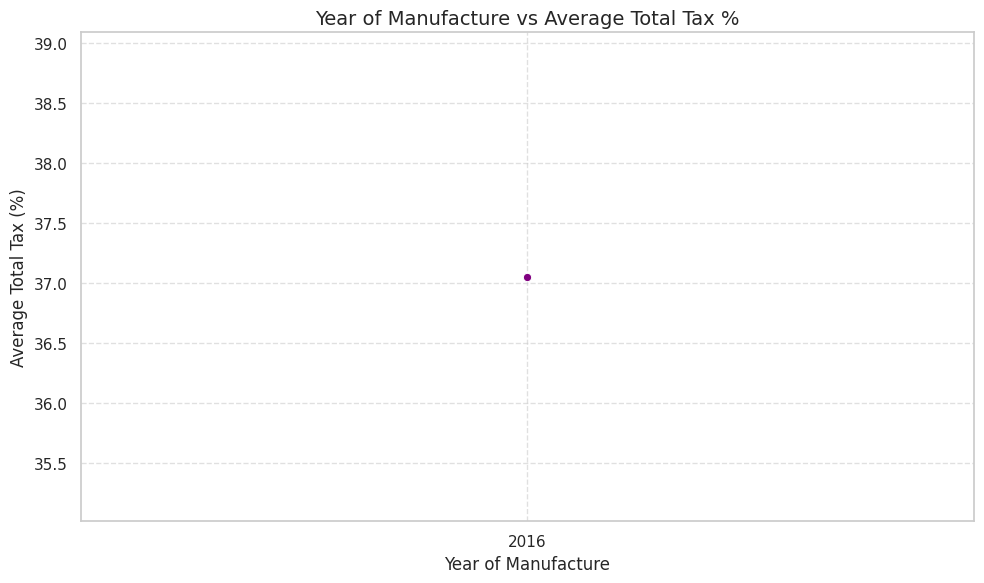

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Year' is numeric so it can be sorted correctly
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Group by Year of Manufacture and calculate the mean Total Tax %
yom_metrics = df.groupby('Year')['Total Tax %'].mean().reset_index()
yom_metrics = yom_metrics.sort_values('Year')

# Plot Year of Manufacture vs Total Tax %
plt.figure(figsize=(10, 6))
sns.lineplot(data=yom_metrics, x='Year', y='Total Tax %', marker='o', linewidth=2.5, color='purple')
plt.title('Year of Manufacture vs Average Total Tax %', fontsize=14)
plt.xlabel('Year of Manufacture')
plt.ylabel('Average Total Tax (%)')
plt.xticks(yom_metrics['Year'].dropna().unique())
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

=== Impact on Total Tax % (Specified Fields Only) ===


,Importance Score
Trim Level,0.557651
Origin,0.432196
HS Code,0.010152
Model,0.000000


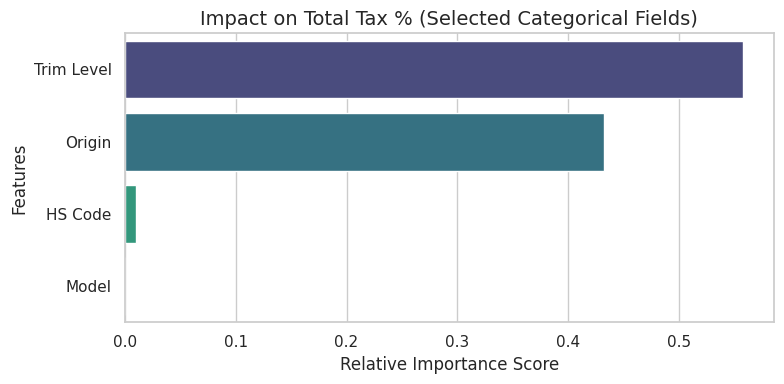

In [35]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# The 4 categorical fields requested
cat_features = ['Trim Level', 'Model', 'Origin', 'HS Code']

# Prepare data by dropping missing values and encoding
rf_cat_df = df.dropna(subset=cat_features + ['Total Tax %']).copy()

le = LabelEncoder()
for col in cat_features:
    rf_cat_df[col] = le.fit_transform(rf_cat_df[col].astype(str))

X_cat = rf_cat_df[cat_features]
y_cat = rf_cat_df['Total Tax %']

# Train the model
rf_cat = RandomForestRegressor(n_estimators=100, random_state=42)
rf_cat.fit(X_cat, y_cat)

# Get feature importances and sort in descending order
cat_importances = pd.Series(rf_cat.feature_importances_, index=cat_features).sort_values(ascending=False)

print("=== Impact on Total Tax % (Specified Fields Only) ===")
display(cat_importances.to_frame('Importance Score'))

# Plot the results
plt.figure(figsize=(8, 4))
sns.barplot(x=cat_importances.values, y=cat_importances.index, hue=cat_importances.index, palette='viridis', legend=False)
plt.title('Impact on Total Tax % (Selected Categorical Fields)', fontsize=14)
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


=== Average Total Tax % by Trim Level (Ascending) ===


,Trim Level,Total Tax %
0,FE+S,36.163385
2,S,36.875799
1,N/A,36.893996
5,SV,36.977002
4,SR,37.763949
3,SL,38.024461


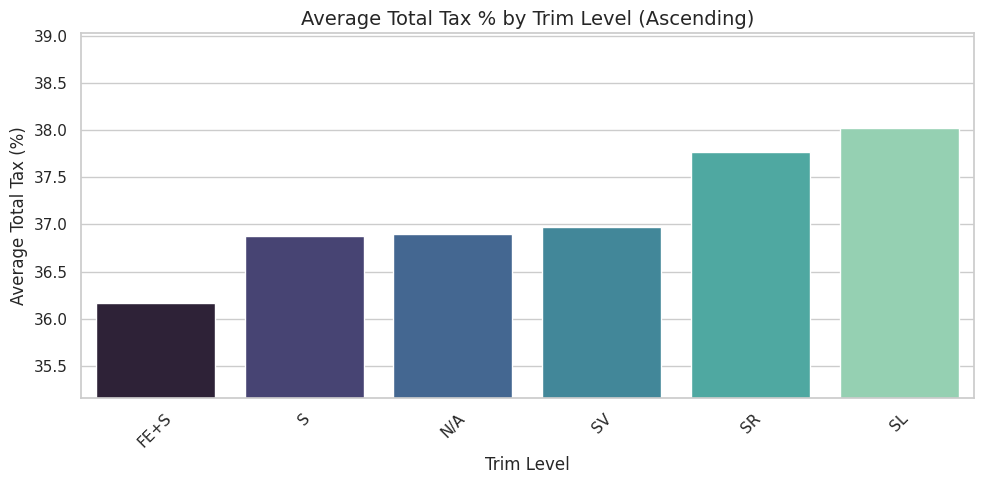


=== Average Total Tax % by Origin (Ascending) ===


,Origin,Total Tax %
0,AE,35.850432
2,US,36.829198
1,CA,38.224424


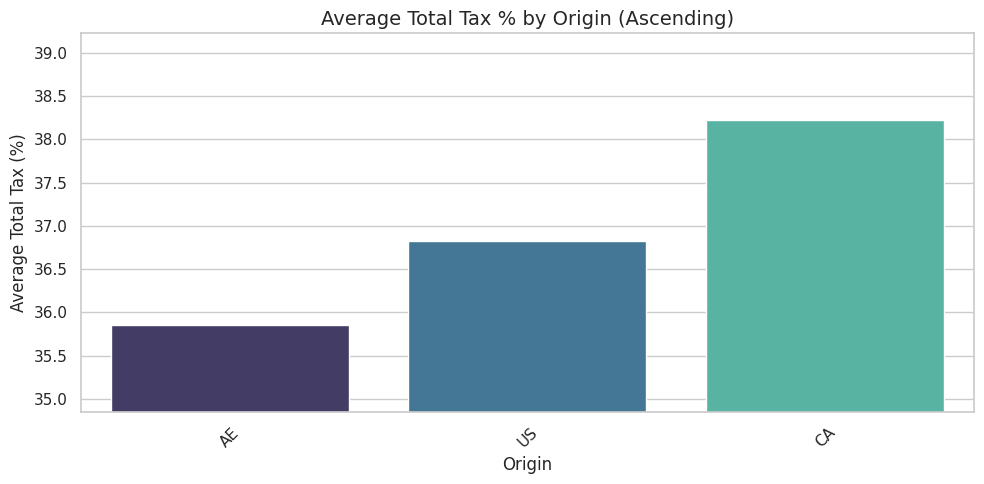


=== Average Total Tax % by HS Code (Ascending) ===


,HS Code,Total Tax %
0,8703222000,36.893996
1,8703232000,37.055203


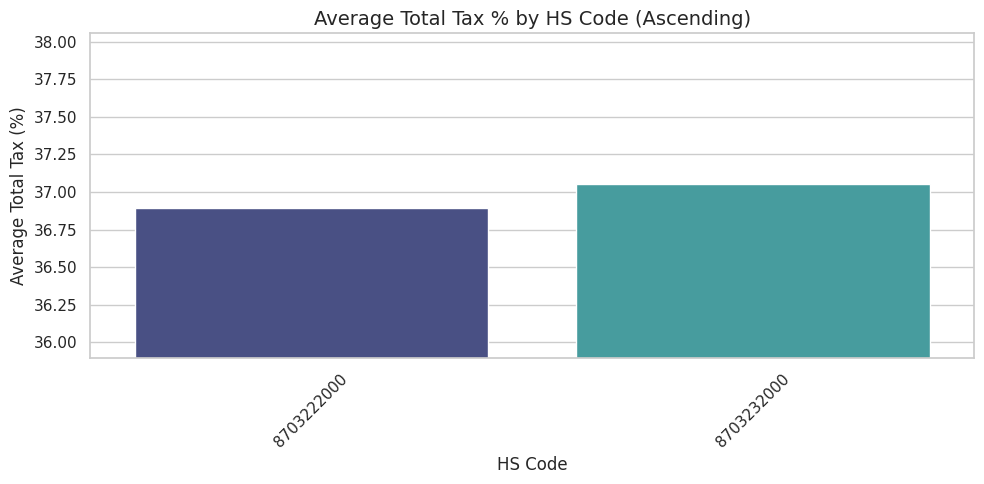

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# The categories we want to break down
features_to_breakdown = ['Trim Level', 'Origin', 'HS Code']

sns.set_theme(style="whitegrid")

for col in features_to_breakdown:
    # Calculate mean Total Tax % for each unique value in the category
    breakdown_df = df.groupby(col)['Total Tax %'].mean().reset_index()

    # Sort in ascending order based on Total Tax %
    breakdown_df = breakdown_df.sort_values(by='Total Tax %', ascending=True)

    print(f"\n=== Average Total Tax % by {col} (Ascending) ===")
    display(breakdown_df)

    # Plot the breakdown
    plt.figure(figsize=(10, 5))
    sns.barplot(data=breakdown_df, x=col, y='Total Tax %', hue=col, palette='mako', legend=False)
    plt.title(f'Average Total Tax % by {col} (Ascending)', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Average Total Tax (%)', fontsize=12)

    # Dynamically adjust y-axis limits to highlight the differences better
    min_val = breakdown_df['Total Tax %'].min()
    max_val = breakdown_df['Total Tax %'].max()
    # Set y-axis to start slightly below the minimum value to zoom in on the differences
    plt.ylim(max(0, min_val - 1), max_val + 1)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


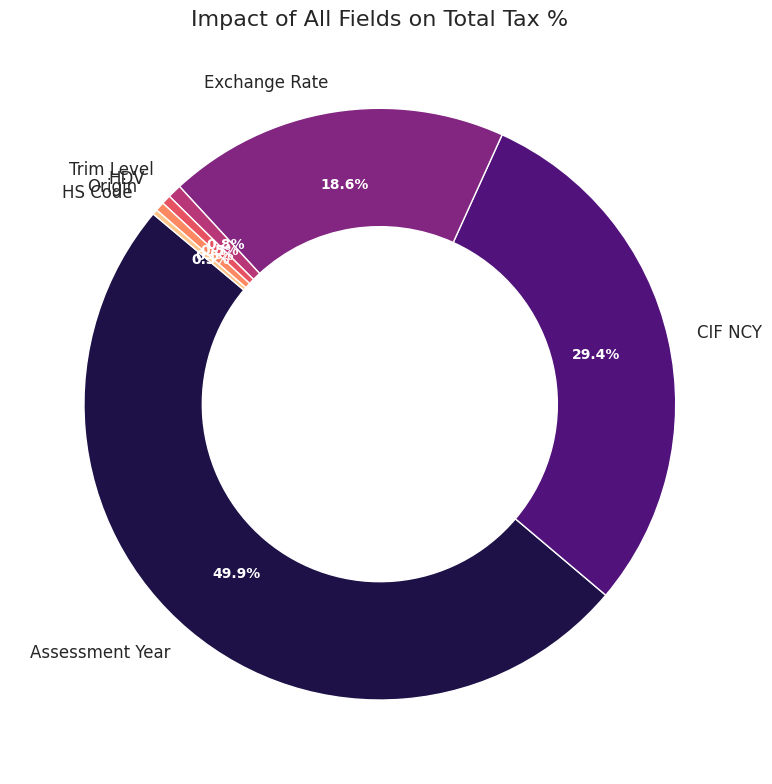

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# We will use the 'weights_pct' variable previously calculated
# which holds the impact weights (%) of all features on Total Tax %

labels = weights_pct.index
sizes = weights_pct.values

# Set up the figure
fig, ax = plt.subplots(figsize=(10, 8))

# Choose a nice color palette
colors = sns.color_palette("magma", len(labels))

# Create a pie chart with a 'width' property to make it a donut
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='white'),
    pctdistance=0.75
)

# Style the text
plt.setp(autotexts, size=10, weight="bold", color="white")
plt.setp(texts, size=12)

# Title and layout
plt.title('Impact of All Fields on Total Tax %', fontsize=16)
plt.tight_layout()
plt.show()


In [38]:
# Summary table: Average CIF NCY by Trim Level
summary_table = df.groupby('Trim Level')['CIF NCY'].mean().reset_index()
summary_table = summary_table.sort_values(by='CIF NCY', ascending=False)

print("=== Average CIF NCY by Trim Level ===")
display(summary_table)

print("\n=== Raw Data: Trim Level and CIF NCY (First 10 Rows) ===")
display(df[['Trim Level', 'CIF NCY']].head(10))


=== Average CIF NCY by Trim Level ===


,Trim Level,CIF NCY
3,SL,115132.760000
4,SR,111309.726000
1,N/A,103446.750000
5,SV,87335.939773
0,FE+S,78650.100000
2,S,76049.428710



=== Raw Data: Trim Level and CIF NCY (First 10 Rows) ===


,Trim Level,CIF NCY
0,S,38740.24
1,SV,42145.74
2,SV,41791.33
3,SR,45491.79
4,S,38165.42
5,SL,45797.46
6,S,38065.19
7,SR,45395.18
8,SV,41651.17
9,S,44712.34


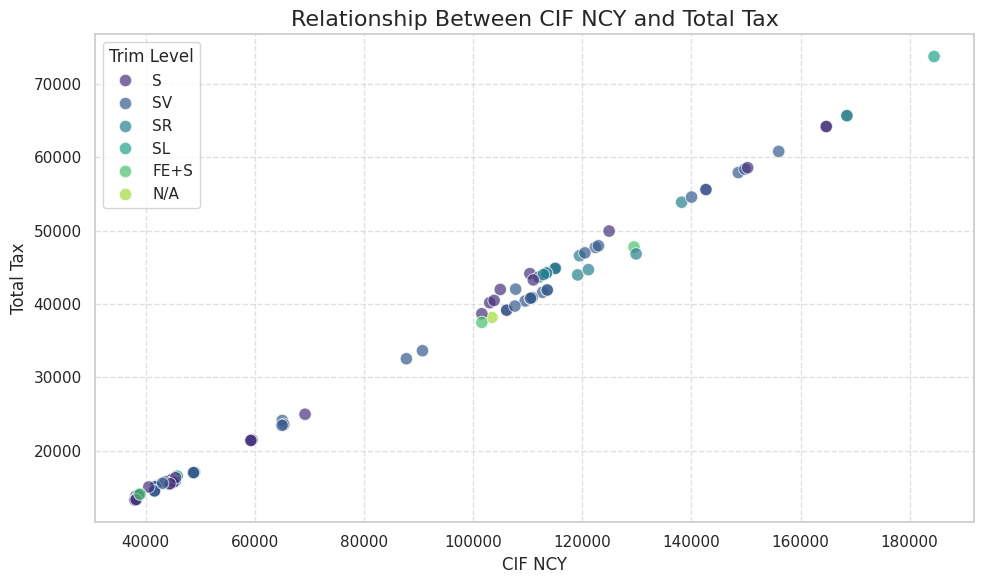

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='CIF NCY', y='Total Tax', hue='Trim Level', palette='viridis', s=80, alpha=0.7)
plt.title('Relationship Between CIF NCY and Total Tax', fontsize=16)
plt.xlabel('CIF NCY', fontsize=12)
plt.ylabel('Total Tax', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [43]:
import pandas as pd
import numpy as np
import re

# Open the new sheet by its ID and read all values
new_sheet_id = "1bIbjqC3s969M3NkuQHgSPDYW_tHQhI0AU2YXUMMKBBg"
new_worksheet = gc.open_by_key(new_sheet_id).sheet1
new_rows = new_worksheet.get_all_values()

# Combine all extracted text into one large string
raw_text = " ".join([str(item) for row in new_rows for item in row])

# Use a regex pattern to extract the row data since it's a single space-separated string
# Matches: No, Trim, Year, Make, Model, HDV, Currency, Origin, HS Code, Exch Rate, Receipt, Assessment, CIF, Tax
pattern = re.compile(r'(\d+)\s+(.*?)\s+(\d{4})\s+(TOYOTA)\s+(CAMRY)\s+([\d,.]+)\s+(USD)\s+([A-Z]{2})\s+(\d+)\s+([\d.]+)\s+(\d{2}/\d{2}/\d{4})\s+(\d{2}/\d{2}/\d{4})\s+([\d,.]+)\s+([\d,.]+)')
matches = pattern.findall(raw_text)

headers = ['No.', 'Trim Level', 'Year', 'Make', 'Model', 'HDV', 'Currency', 'Origin', 'HS Code', 'Exchange Rate', 'Receipt Date', 'Assessment Date', 'CIF NCY', 'Total Tax']

if matches:
    df_new = pd.DataFrame(matches, columns=headers)
else:
    df_new = pd.DataFrame(columns=headers)

# Clean and normalize the data
df_new['Year'] = pd.to_numeric(df_new['Year'], errors='coerce')
numeric_columns = ['HDV', 'Exchange Rate', 'CIF NCY', 'Total Tax']
for col in numeric_columns:
    if col in df_new.columns:
        df_new[col] = df_new[col].astype(str).str.replace(',', '').astype(float)

print("=== First 5 rows of the New Dataset ===")
display(df_new.head())
print(f"Total rows extracted: {len(df_new)}")

# Check if the old data had enough variance to calculate a correlation
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
if df['Year'].nunique() > 1:
    corr_old = df[['Year', 'Total Tax']].corr().loc['Year', 'Total Tax']
    print(f"\nCorrelation between Year of Manufacture and Total Tax (Old Data): {corr_old:.4f}")
else:
    print(f"\nCannot calculate correlation for Old Data. It only contains the year {df['Year'].unique()[0]}.")

# Calculate correlation for the new data
if df_new['Year'].nunique() > 1:
    corr_new = df_new[['Year', 'Total Tax']].corr().loc['Year', 'Total Tax']
    print(f"\nCorrelation between Year of Manufacture and Total Tax (New Data): {corr_new:.4f}")
else:
    print("\nNot enough variance in Year to calculate correlation in New Data.")


=== First 5 rows of the New Dataset ===


,No.,Trim Level,Year,Make,Model,HDV,Currency,Origin,HS Code,Exchange Rate,Receipt Date,Assessment Date,CIF NCY,Total Tax
0,1,XLE,2017,TOYOTA,CAMRY,26310.0,USD,CA,8703232000,5.8692,05/10/2021,28/09/2021,70449.88,25406.81
1,2,SE,2017,TOYOTA,CAMRY,23840.0,USD,US,8703232000,5.7327,08/04/2021,09/04/2021,62812.28,21870.79
2,3,SE,2017,TOYOTA,CAMRY,23840.0,USD,US,8703232000,5.7670,12/07/2021,08/07/2021,63188.10,22785.91
3,4,XSE,2017,TOYOTA,CAMRY,26310.0,USD,CA,8703232000,5.7297,03/04/2021,03/04/2021,68775.43,23949.30
4,5,SE,2017,TOYOTA,CAMRY,23840.0,USD,US,8703232000,5.7163,03/12/2020,03/12/2020,62632.64,21808.23


Total rows extracted: 89

Cannot calculate correlation for Old Data. It only contains the year 2016.

Correlation between Year of Manufacture and Total Tax (New Data): 0.8587


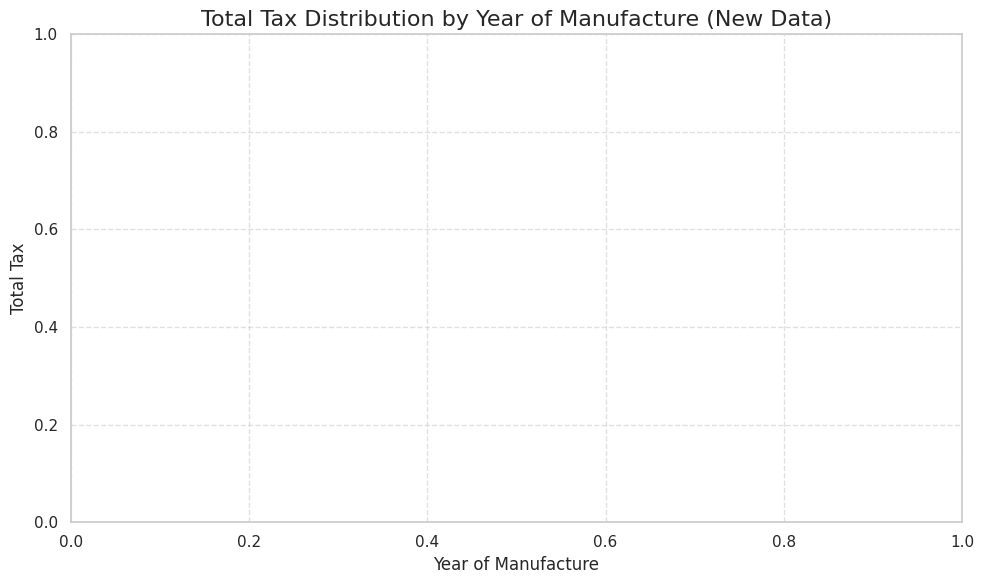

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the relationship in the new dataset
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_new, x='Year', y='Total Tax', palette='Set2')
sns.stripplot(data=df_new, x='Year', y='Total Tax', color='black', alpha=0.5, jitter=True)
plt.title('Total Tax Distribution by Year of Manufacture (New Data)', fontsize=16)
plt.xlabel('Year of Manufacture', fontsize=12)
plt.ylabel('Total Tax', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

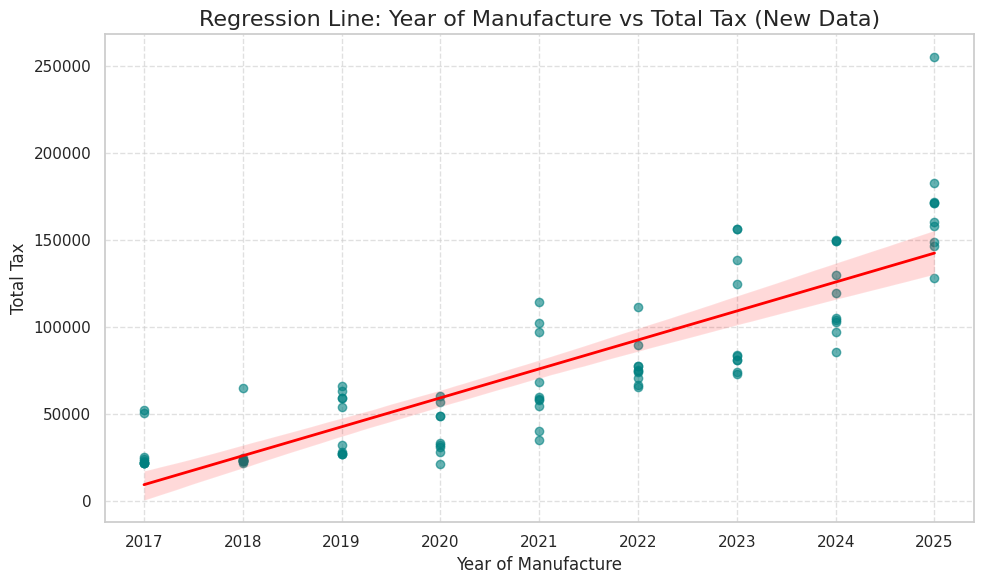

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot with a regression line for the new dataset
plt.figure(figsize=(10, 6))
sns.regplot(data=df_new, x='Year', y='Total Tax',
            scatter_kws={'alpha': 0.6, 'color': 'teal'},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('Regression Line: Year of Manufacture vs Total Tax (New Data)', fontsize=16)
plt.xlabel('Year of Manufacture', fontsize=12)
plt.ylabel('Total Tax', fontsize=12)

# Ensure the x-axis displays integer years
plt.xticks(sorted(df_new['Year'].dropna().unique()))
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

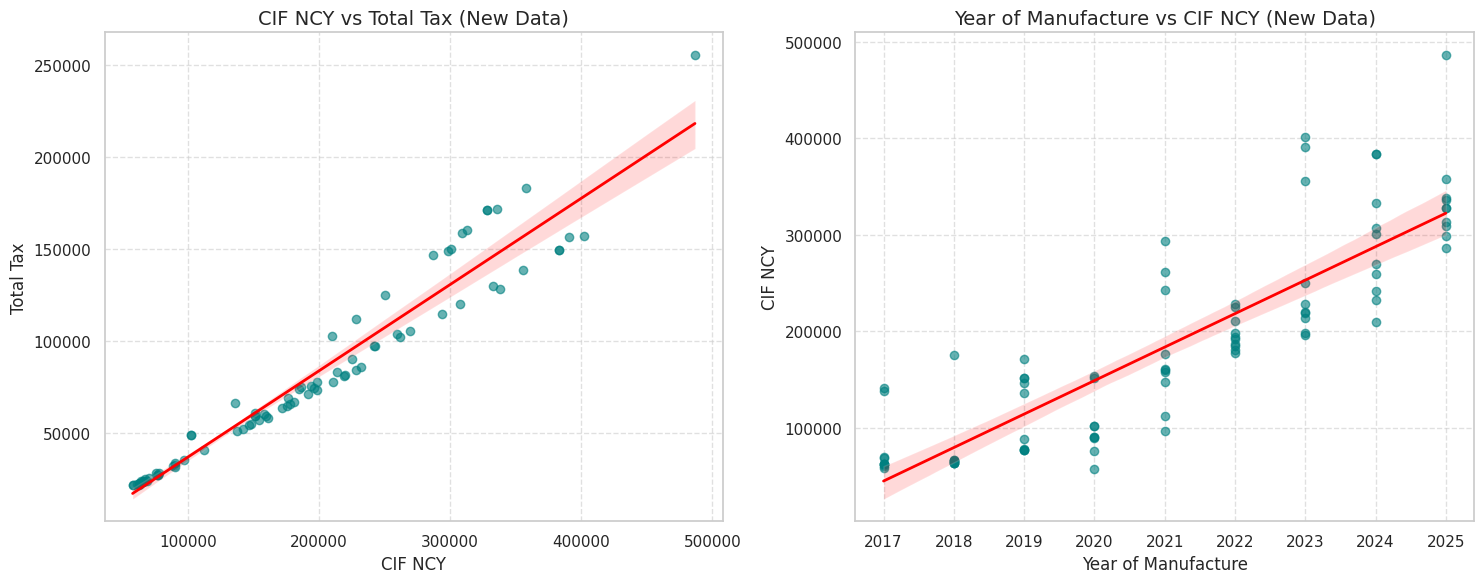

=== Correlation Results Table ===


,Relationship,Correlation Score
0,CIF NCY vs Total Tax,0.971362
1,Year of Manufacture vs CIF NCY,0.863896


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set up the figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Regression plot: CIF NCY vs Total Tax
sns.regplot(data=df_new, x='CIF NCY', y='Total Tax',
            scatter_kws={'alpha': 0.6, 'color': 'teal'},
            line_kws={'color': 'red', 'linewidth': 2}, ax=axes[0])
axes[0].set_title('CIF NCY vs Total Tax (New Data)', fontsize=14)
axes[0].set_xlabel('CIF NCY', fontsize=12)
axes[0].set_ylabel('Total Tax', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Regression plot: Year of Manufacture vs CIF NCY
sns.regplot(data=df_new, x='Year', y='CIF NCY',
            scatter_kws={'alpha': 0.6, 'color': 'teal'},
            line_kws={'color': 'red', 'linewidth': 2}, ax=axes[1])
axes[1].set_title('Year of Manufacture vs CIF NCY (New Data)', fontsize=14)
axes[1].set_xlabel('Year of Manufacture', fontsize=12)
axes[1].set_ylabel('CIF NCY', fontsize=12)
axes[1].set_xticks(sorted(df_new['Year'].dropna().unique()))
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Calculate correlations and print the results table
corr_cif_tax = df_new[['CIF NCY', 'Total Tax']].corr().iloc[0, 1]
corr_year_cif = df_new[['Year', 'CIF NCY']].corr().iloc[0, 1]

results_table = pd.DataFrame({
    'Relationship': ['CIF NCY vs Total Tax', 'Year of Manufacture vs CIF NCY'],
    'Correlation Score': [corr_cif_tax, corr_year_cif]
})

print("=== Correlation Results Table ===")
display(results_table)

In [46]:
import pandas as pd

# Group by Year of Manufacture and calculate the average Total Tax
summary_year_tax = df_new.groupby('Year')['Total Tax'].mean().reset_index()
summary_year_tax = summary_year_tax.sort_values(by='Year')

print("=== Average Total Tax by Year of Manufacture (New Data) ===")
display(summary_year_tax)

print("\n=== Raw Data: Year of Manufacture and Total Tax (First 15 Rows) ===")
# Sort by year to show the progression in the raw data sample
display(df_new[['Year', 'Total Tax']].sort_values(by='Year').head(15))

=== Average Total Tax by Year of Manufacture (New Data) ===


,Year,Total Tax
0,2017,28449.020000
1,2018,27463.784000
2,2019,44262.815000
3,2020,40181.163333
4,2021,68948.048000
5,2022,78443.692000
6,2023,105370.310000
7,2024,119345.905000
8,2025,169593.949000



=== Raw Data: Year of Manufacture and Total Tax (First 15 Rows) ===


,Year,Total Tax
0,2017,25406.81
1,2017,21870.79
2,2017,22785.91
3,2017,23949.30
4,2017,21808.23
5,2017,21615.25
6,2017,22041.24
7,2017,21858.19
8,2017,50860.78
9,2017,52293.70


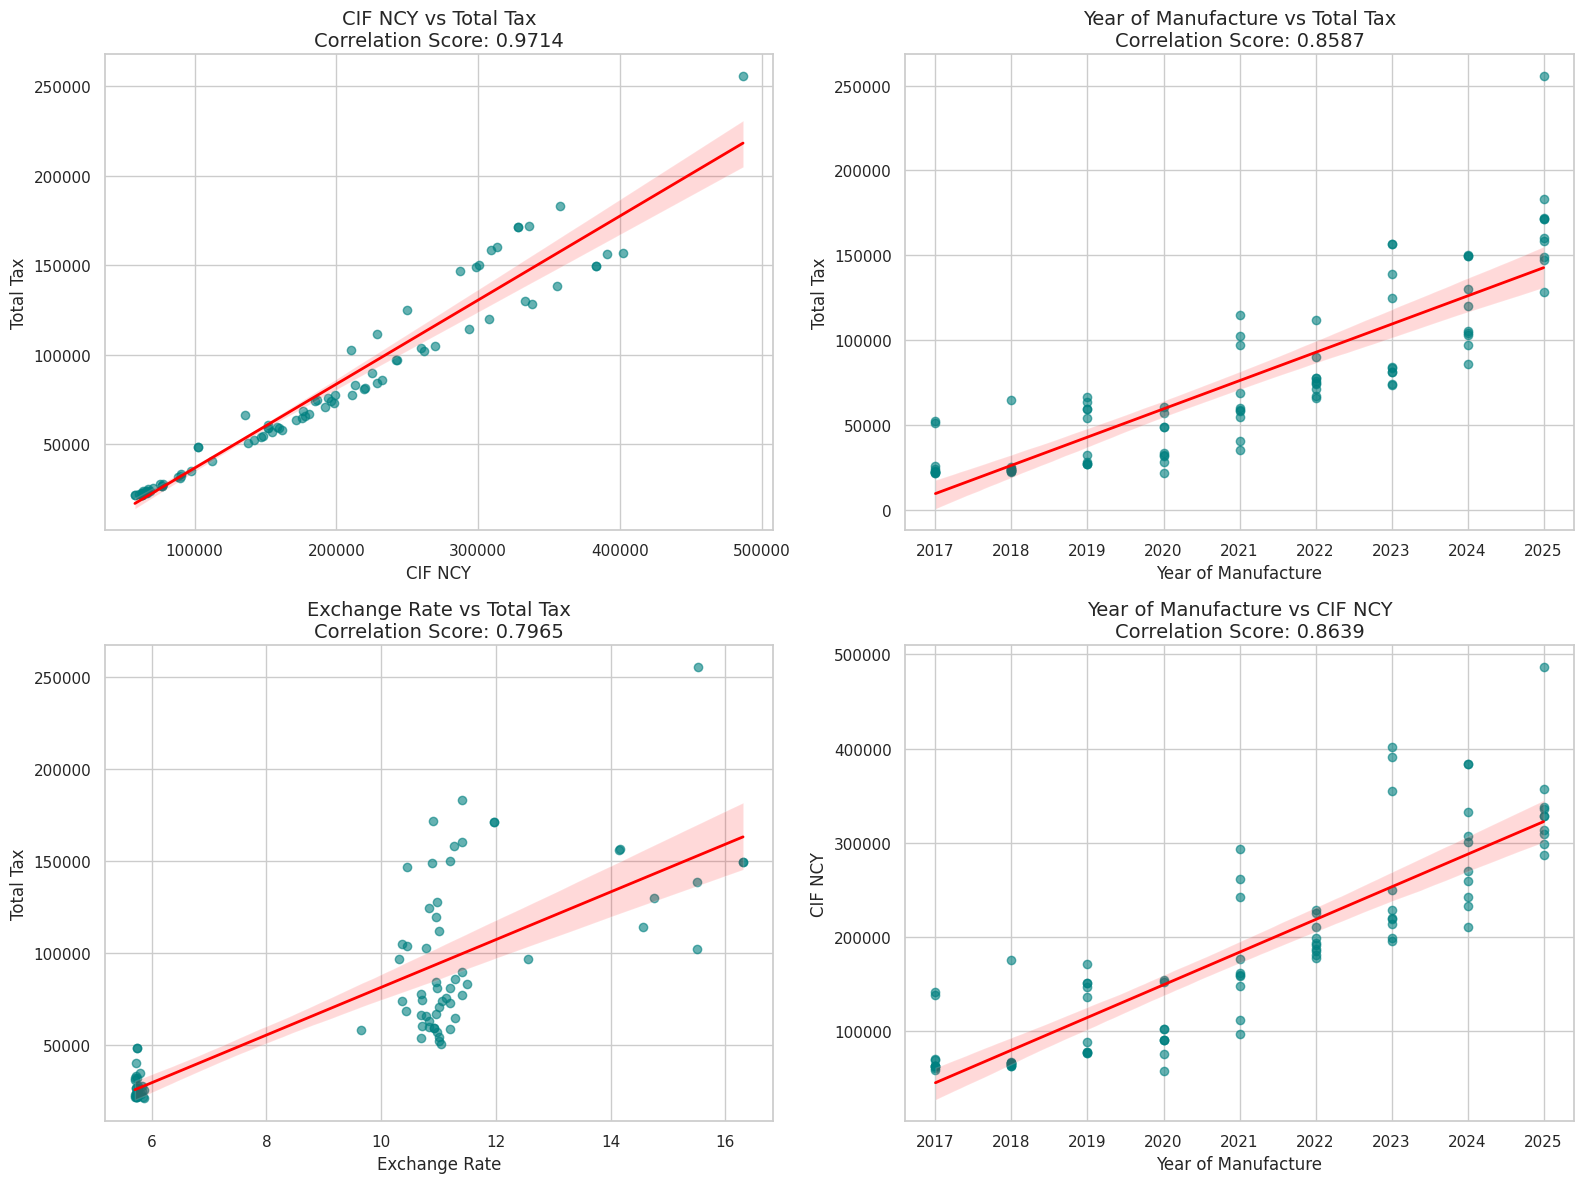

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate correlations
corr_cif_tax = df_new[['CIF NCY', 'Total Tax']].corr().iloc[0, 1]
corr_year_tax = df_new[['Year', 'Total Tax']].corr().iloc[0, 1]
corr_exch_tax = df_new[['Exchange Rate', 'Total Tax']].corr().iloc[0, 1]
corr_year_cif = df_new[['Year', 'CIF NCY']].corr().iloc[0, 1]

# Set up a 2x2 grid for the plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# 1. CIF NCY vs Total Tax
sns.regplot(data=df_new, x='CIF NCY', y='Total Tax', ax=axes[0, 0],
            scatter_kws={'alpha': 0.6, 'color': 'teal'},
            line_kws={'color': 'red', 'linewidth': 2})
axes[0, 0].set_title(f'CIF NCY vs Total Tax\nCorrelation Score: {corr_cif_tax:.4f}', fontsize=14)
axes[0, 0].set_xlabel('CIF NCY', fontsize=12)
axes[0, 0].set_ylabel('Total Tax', fontsize=12)

# 2. Year of Manufacture vs Total Tax
sns.regplot(data=df_new, x='Year', y='Total Tax', ax=axes[0, 1],
            scatter_kws={'alpha': 0.6, 'color': 'teal'},
            line_kws={'color': 'red', 'linewidth': 2})
axes[0, 1].set_title(f'Year of Manufacture vs Total Tax\nCorrelation Score: {corr_year_tax:.4f}', fontsize=14)
axes[0, 1].set_xlabel('Year of Manufacture', fontsize=12)
axes[0, 1].set_ylabel('Total Tax', fontsize=12)
axes[0, 1].set_xticks(sorted(df_new['Year'].dropna().unique()))

# 3. Exchange Rate vs Total Tax
sns.regplot(data=df_new, x='Exchange Rate', y='Total Tax', ax=axes[1, 0],
            scatter_kws={'alpha': 0.6, 'color': 'teal'},
            line_kws={'color': 'red', 'linewidth': 2})
axes[1, 0].set_title(f'Exchange Rate vs Total Tax\nCorrelation Score: {corr_exch_tax:.4f}', fontsize=14)
axes[1, 0].set_xlabel('Exchange Rate', fontsize=12)
axes[1, 0].set_ylabel('Total Tax', fontsize=12)

# 4. Year of Manufacture vs CIF NCY
sns.regplot(data=df_new, x='Year', y='CIF NCY', ax=axes[1, 1],
            scatter_kws={'alpha': 0.6, 'color': 'teal'},
            line_kws={'color': 'red', 'linewidth': 2})
axes[1, 1].set_title(f'Year of Manufacture vs CIF NCY\nCorrelation Score: {corr_year_cif:.4f}', fontsize=14)
axes[1, 1].set_xlabel('Year of Manufacture', fontsize=12)
axes[1, 1].set_ylabel('CIF NCY', fontsize=12)
axes[1, 1].set_xticks(sorted(df_new['Year'].dropna().unique()))

plt.tight_layout()
plt.show()

In [48]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# 1. Reverse Engineer formula using Multiple Variables (Finding the Weights)
# We'll use the newer dataset (df_new) as it has more variance in Year and Prices
features = ['CIF NCY', 'Year', 'Exchange Rate', 'HDV']

# Prepare the data, dropping any rows with missing values in these columns
analysis_df = df_new.dropna(subset=features + ['Total Tax']).copy()
X_multi = analysis_df[features]
y_multi = analysis_df['Total Tax']

multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)

print("="*50)
print("REVERSE ENGINEERED ALGORITHM WEIGHTS (MULTIPLE FIELDS)")
print("="*50)
print("If we consider all fields, the Total Tax formula is approximately:")
print(f"Total Tax = ")
for col, coef in zip(X_multi.columns, multi_model.coef_):
    print(f"  + ({coef:.4f} * {col})")
print(f"  + {multi_model.intercept_:.4f} (Base Intercept/Fixed Fee)\n")

# 2. Formula based primarily on CIF NCY for the requested breakdown function
# Since CIF NCY alone has a 0.97 correlation with Total Tax, it acts as the master variable.
# We will extract its specific proportional and fixed weights for the calculator.
cif_model = LinearRegression()
X_cif = analysis_df[['CIF NCY']]
y_cif = analysis_df['Total Tax']
cif_model.fit(X_cif, y_cif)

cif_weight = cif_model.coef_[0]
intercept = cif_model.intercept_

print("="*50)
print("SIMPLIFIED CIF-ONLY FORMULA")
print("="*50)
print(f"Total Tax = ({cif_weight:.4f} * CIF NCY) {intercept:+.4f}\n")

# 3. Create the function to request CIF and print the breakdown
def estimate_total_tax(cif_value):
    """
    Takes a requested CIF NCY value and breaks down the estimated Total Tax
    based on our reverse-engineered linear algorithm.
    """
    proportional_tax = cif_value * cif_weight
    estimated_total = proportional_tax + intercept

    print(f"--- Tax Breakdown for Requested CIF NCY: {cif_value:,.2f} ---")
    print(f"1. Proportional Tax Component ({cif_weight*100:.2f}% of CIF): {proportional_tax:,.2f}")
    print(f"2. Fixed Administrative/Base Fee (Intercept):         {intercept:,.2f}")
    print("-" * 55)
    print(f"ESTIMATED TOTAL TAX:                                {estimated_total:,.2f}")
    print("=" * 55 + "\n")

# Let's test the algorithm with a few sample CIF values
print("=== Testing the Algorithm with Sample CIF Values ===\n")
estimate_total_tax(50000)
estimate_total_tax(100000)
estimate_total_tax(250000)

REVERSE ENGINEERED ALGORITHM WEIGHTS (MULTIPLE FIELDS)
If we consider all fields, the Total Tax formula is approximately:
Total Tax = 
  + (0.5653 * CIF NCY)
  + (148.8084 * Year)
  + (-3854.3063 * Exchange Rate)
  + (0.0449 * HDV)
  + -292915.0404 (Base Intercept/Fixed Fee)

SIMPLIFIED CIF-ONLY FORMULA
Total Tax = (0.4692 * CIF NCY) -10203.5753

=== Testing the Algorithm with Sample CIF Values ===

--- Tax Breakdown for Requested CIF NCY: 50,000.00 ---
1. Proportional Tax Component (46.92% of CIF): 23,458.01
2. Fixed Administrative/Base Fee (Intercept):         -10,203.58
-------------------------------------------------------
ESTIMATED TOTAL TAX:                                13,254.44

--- Tax Breakdown for Requested CIF NCY: 100,000.00 ---
1. Proportional Tax Component (46.92% of CIF): 46,916.02
2. Fixed Administrative/Base Fee (Intercept):         -10,203.58
-------------------------------------------------------
ESTIMATED TOTAL TAX:                                36,712.45

--- 

In [49]:
# Request user input for a CIF value
user_input = input("Please enter the CIF NCY value to estimate the Total Tax: ")

try:
    # Clean the input (remove commas in case the user typed them) and convert to float
    clean_cif_value = float(user_input.replace(',', ''))

    # Add some spacing for readability
    print("\n")

    # Call the breakdown function we created in the previous cell
    estimate_total_tax(clean_cif_value)

except ValueError:
    print("Invalid input. Please run this cell again and enter a valid numeric value.")

Please enter the CIF NCY value to estimate the Total Tax: 11000


--- Tax Breakdown for Requested CIF NCY: 11,000.00 ---
1. Proportional Tax Component (46.92% of CIF): 5,160.76
2. Fixed Administrative/Base Fee (Intercept):         -10,203.58
-------------------------------------------------------
ESTIMATED TOTAL TAX:                                -5,042.81



In [50]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Install PyPDF2 quietly
!pip install -q PyPDF2
print("Drive mounted and PyPDF2 installed successfully!")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 4.8 MB/s eta 0:00:00
Drive mounted and PyPDF2 installed successfully!


In [51]:
import PyPDF2

# Define the path to your PDF file in Google Drive
file_path = '/content/drive/My Drive/2026/baobab/baobab_1/TM1/ICUMS/2024 BYD Dolphin Hatchback 4D.pdf'

try:
    # Open the PDF file in read-binary mode
    with open(file_path, 'rb') as file:
        reader = PyPDF2.PdfReader(file)
        num_pages = len(reader.pages)
        print(f"Successfully loaded PDF. Total pages: {num_pages}\n")

        # Extract and print text from the first page as a preview
        if num_pages > 0:
            first_page_text = reader.pages[0].extract_text()
            print("=== Preview of Page 1 ===")
            print(first_page_text[:1500]) # Print up to 1500 characters
        else:
            print("The PDF appears to be empty.")

except FileNotFoundError:
    print(f"Error: File not found at '{file_path}'.")
    print("Please double-check the path, folder names, and ensure the file exists in your Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded PDF. Total pages: 1

=== Preview of Page 1 ===
2AS2533838C May 19,2026
2024 BYD Dolphin Hatchback 4D
Type Fuel &CC Weight Seats OnArrival FXRate
Normal Electric 355 3283 5 2.4yrs 11.2806
LC0CE4CC0S5388726
Taxes &Duty Payable
# Descriptor Base Amt Rate Payable
01 Import Duty 197,283.40 0.20 39,456.68
02 Import VAT 248,577.09 0.15 37,286.56
05 Processing Fee 197,283.40 0.00 0.00
06 ECOWAS Levy 197,283.40 0.01 986.42
16 Vehicle Certification 0.50 1.00 0.50
31 Vehicle Examination Fee 197,283.40 0.01 1,972.83
32 Network Charge 189,187.33 0.00 756.75
33 Network Charge VAT 783.24 0.15 117.49
39 Network Charge COVID-19 Health 0.00 0.00 0.00
45 Ghana Shippers Authority SNF Fee 9.00 1.00 9.00
47 Import NHIL 9.00 1.00 9.00
48 Network Charge NHIL 756.75 0.03 18.92
49 Overage Penalty 197,283.40 0.00 0.00
56 IRSTaxDeposit 197,283.40 0.00 0.00
63 GHS Disinfection Fee 143.38 1.00 143.38
72 MoTI e-IDF Fee 5.00 1.00 5.00
78 Special Import Levy (2%) 197,283.40 0.02 3,945.67
87Ghana Ex

Combined Dataset Shape: 186 rows

=== Model Performance Comparison (R-squared) ===
1. Nissan-Only Model (Self-Score):  0.9991
2. Toyota-Only Model (Self-Score):  0.9880
3. Unified Model (Training Score):  0.9932
4. Unified Model (Testing Score):   0.9516  <-- True Generalized Score

=== Testing the BYD Dolphin (Out of Sample) ===
Vehicle:                     2024 BYD Dolphin (Electric)
Actual Total Tax (from PDF): 100,390.79 GHS
Unified Model Prediction:    76,982.82 GHS
Difference:                  -23,407.97 GHS

Note: The Unified model was trained purely on Internal Combustion Engine (ICE) vehicles.
If there is a large discrepancy, it strongly implies Electric Vehicles (EVs) like the BYD have a different tax structure/discounts in the system.


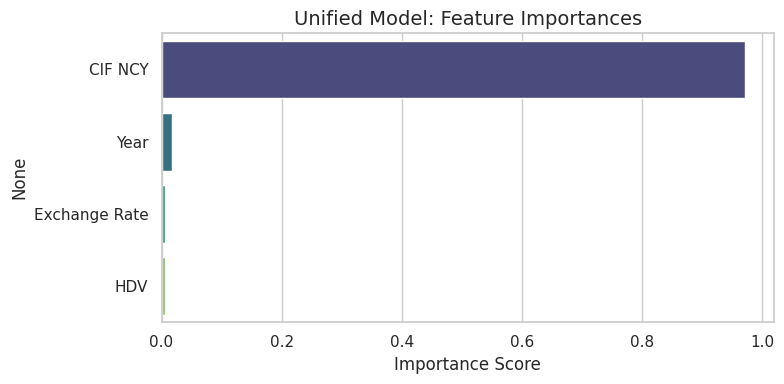

In [52]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Label and Combine Existing Datasets
df['Dataset'] = 'Nissan Sentra (Old)'
df_new['Dataset'] = 'Toyota Camry (New)'

df_combined = pd.concat([df, df_new], ignore_index=True)
print(f"Combined Dataset Shape: {df_combined.shape[0]} rows")

# 2. Extract BYD Dolphin data from PDF into a DataFrame
# Using the base amount (197,283.40) as CIF NCY, and FX Rate (11.2806)
# HDV is estimated roughly as CIF / Exchange Rate
byd_data = {
    'Make': 'BYD',
    'Model': 'Dolphin',
    'Year': 2024,
    'Exchange Rate': 11.2806,
    'CIF NCY': 197283.40,
    'Total Tax': 100390.79,
    'HDV': 197283.40 / 11.2806,
    'Dataset': 'BYD Dolphin (PDF)'
}
byd_df = pd.DataFrame([byd_data])

# 3. Prepare Features for Modeling
features = ['CIF NCY', 'Year', 'Exchange Rate', 'HDV']
target = 'Total Tax'

# Clean data to ensure no NaNs in target or features
model_df = df_combined.dropna(subset=features + [target]).copy()

# 4. Train Individual Models
# Model 1: Nissan Sentra Only
nissan_df = model_df[model_df['Dataset'] == 'Nissan Sentra (Old)']
X_nissan, y_nissan = nissan_df[features], nissan_df[target]
rf_nissan = RandomForestRegressor(random_state=42).fit(X_nissan, y_nissan)
nissan_r2 = r2_score(y_nissan, rf_nissan.predict(X_nissan))

# Model 2: Toyota Camry Only
toyota_df = model_df[model_df['Dataset'] == 'Toyota Camry (New)']
X_toyota, y_toyota = toyota_df[features], toyota_df[target]
rf_toyota = RandomForestRegressor(random_state=42).fit(X_toyota, y_toyota)
toyota_r2 = r2_score(y_toyota, rf_toyota.predict(X_toyota))

# 5. Train Unified Model (with Train/Test Split for generalization)
X_all = model_df[features]
y_all = model_df[target]
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

rf_unified = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)
unified_r2_train = rf_unified.score(X_train, y_train)
unified_r2_test = rf_unified.score(X_test, y_test)

# Display Model Comparison
print("\n=== Model Performance Comparison (R-squared) ===")
print(f"1. Nissan-Only Model (Self-Score):  {nissan_r2:.4f}")
print(f"2. Toyota-Only Model (Self-Score):  {toyota_r2:.4f}")
print(f"3. Unified Model (Training Score):  {unified_r2_train:.4f}")
print(f"4. Unified Model (Testing Score):   {unified_r2_test:.4f}  <-- True Generalized Score")

# 6. Test the BYD Dolphin against the Unified Model
byd_X = byd_df[features]
byd_actual = byd_df[target].values[0]
byd_pred = rf_unified.predict(byd_X)[0]

print("\n=== Testing the BYD Dolphin (Out of Sample) ===")
print(f"Vehicle:                     2024 BYD Dolphin (Electric)")
print(f"Actual Total Tax (from PDF): {byd_actual:,.2f} GHS")
print(f"Unified Model Prediction:    {byd_pred:,.2f} GHS")
print(f"Difference:                  {byd_pred - byd_actual:,.2f} GHS")
print("\nNote: The Unified model was trained purely on Internal Combustion Engine (ICE) vehicles.")
print("If there is a large discrepancy, it strongly implies Electric Vehicles (EVs) like the BYD have a different tax structure/discounts in the system.")

# Plot feature importances of the unified model
importances = pd.Series(rf_unified.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Unified Model: Feature Importances', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


In [53]:
# Test the BYD Dolphin against the Nissan-Only Model
byd_pred_nissan = rf_nissan.predict(byd_X)[0]

print("=== Testing the BYD Dolphin (Nissan-Only Model) ===")
print(f"Vehicle:                     2024 BYD Dolphin (Electric)")
print(f"Actual Total Tax (from PDF): {byd_actual:,.2f} GHS")
print(f"Nissan Model Prediction:     {byd_pred_nissan:,.2f} GHS")
print(f"Difference:                  {byd_pred_nissan - byd_actual:,.2f} GHS")
print("\nNote: The Nissan model was trained purely on older ICE vehicles (2016 Sentras).")
print("Let's see if it gets closer to the EV's actual tax than the Unified Model did.")

=== Testing the BYD Dolphin (Nissan-Only Model) ===
Vehicle:                     2024 BYD Dolphin (Electric)
Actual Total Tax (from PDF): 100,390.79 GHS
Nissan Model Prediction:     60,092.62 GHS
Difference:                  -40,298.17 GHS

Note: The Nissan model was trained purely on older ICE vehicles (2016 Sentras).
Let's see if it gets closer to the EV's actual tax than the Unified Model did.


In [54]:
import pandas as pd
import io

# The raw Tesla data provided
tesla_raw_data = """No.	Trim Level	Year of Manufacture	Make	Model	HDV	Currency	Origin Code	HS Code	Excange Rate	Receipt Date	Assessment Date	CIF NCY	Total Tax
1	NIL	2023	TESLA	MODEL 3	38,990	USD	CA	8703802000	11.4182		18/05/2026	275,973.9	134,991.52
2	NA	2023	TESLA	MODEL 3	38,990	USD	US	8703802000	10.9755	02/04/2026	26/03/2026	265,273.99	129,757.71
1	AS ADDR	2023	TESLA	MODEL X	79,990	USD	DE	8703802000	11.1341	05/10/2023	02/10/2023	775,390.08	397,042.1
1	PERFORMANCE	2023	TESLA	MODEL Y	52,490	USD	US	8703802000	11.4157	11/12/2025	08/12/2025	373,726.85	191,342.51"""

# Read into a pandas DataFrame using tab separator
tesla_df = pd.read_csv(io.StringIO(tesla_raw_data), sep='\t')

# Clean numeric columns (remove commas, convert to float)
numeric_columns = ['HDV', 'Excange Rate', 'CIF NCY', 'Total Tax']
for col in numeric_columns:
    if col in tesla_df.columns:
        tesla_df[col] = tesla_df[col].astype(str).str.replace(',', '').astype(float)

# Standardize column names to match existing models
tesla_df = tesla_df.rename(columns={'Excange Rate': 'Exchange Rate', 'Year of Manufacture': 'Year'})
tesla_df['Dataset'] = 'Tesla (EV)'

print("=== Parsed Tesla Data ===")
display(tesla_df[['Year', 'Make', 'Model', 'HDV', 'Exchange Rate', 'CIF NCY', 'Total Tax']])

# Test the Tesla data against the Unified Model
features = ['CIF NCY', 'Year', 'Exchange Rate', 'HDV']
tesla_X = tesla_df[features]

# Predict using the Unified ICE Model
tesla_df['Unified Prediction (ICE)'] = rf_unified.predict(tesla_X)
tesla_df['Difference'] = tesla_df['Unified Prediction (ICE)'] - tesla_df['Total Tax']

print("\n=== Testing Tesla EVs against the Unified Model ===")
display(tesla_df[['Model', 'CIF NCY', 'Total Tax', 'Unified Prediction (ICE)', 'Difference']])

=== Parsed Tesla Data ===


,Year,Make,Model,HDV,Exchange Rate,CIF NCY,Total Tax
0,2023,TESLA,MODEL 3,38990.0,11.4182,275973.90,134991.52
1,2023,TESLA,MODEL 3,38990.0,10.9755,265273.99,129757.71
2,2023,TESLA,MODEL X,79990.0,11.1341,775390.08,397042.10
3,2023,TESLA,MODEL Y,52490.0,11.4157,373726.85,191342.51



=== Testing Tesla EVs against the Unified Model ===


,Model,CIF NCY,Total Tax,Unified Prediction (ICE),Difference
0,MODEL 3,275973.90,134991.52,116718.94140,-18272.57860
1,MODEL 3,265273.99,129757.71,114909.77825,-14847.93175
2,MODEL X,775390.08,397042.10,200403.53920,-196638.56080
3,MODEL Y,373726.85,191342.51,152371.93920,-38970.57080


In [55]:
import pandas as pd

# Select common relevant columns for the EV dataset
ev_columns = ['Dataset', 'Make', 'Model', 'Year', 'HDV', 'Exchange Rate', 'CIF NCY', 'Total Tax']

# Extract the subsets from our existing dataframes
byd_subset = byd_df[ev_columns].copy()
tesla_subset = tesla_df[ev_columns].copy()

# Combine the BYD and Tesla data into a new EV dataset
ev_df = pd.concat([byd_subset, tesla_subset], ignore_index=True)

print("=== Combined EV Tax Dataset ===")
print(f"Total EV Records: {len(ev_df)}")
display(ev_df)

=== Combined EV Tax Dataset ===
Total EV Records: 5


,Dataset,Make,Model,Year,HDV,Exchange Rate,CIF NCY,Total Tax
0,BYD Dolphin (PDF),BYD,Dolphin,2024,17488.732869,11.2806,197283.40,100390.79
1,Tesla (EV),TESLA,MODEL 3,2023,38990.000000,11.4182,275973.90,134991.52
2,Tesla (EV),TESLA,MODEL 3,2023,38990.000000,10.9755,265273.99,129757.71
3,Tesla (EV),TESLA,MODEL X,2023,79990.000000,11.1341,775390.08,397042.10
4,Tesla (EV),TESLA,MODEL Y,2023,52490.000000,11.4157,373726.85,191342.51


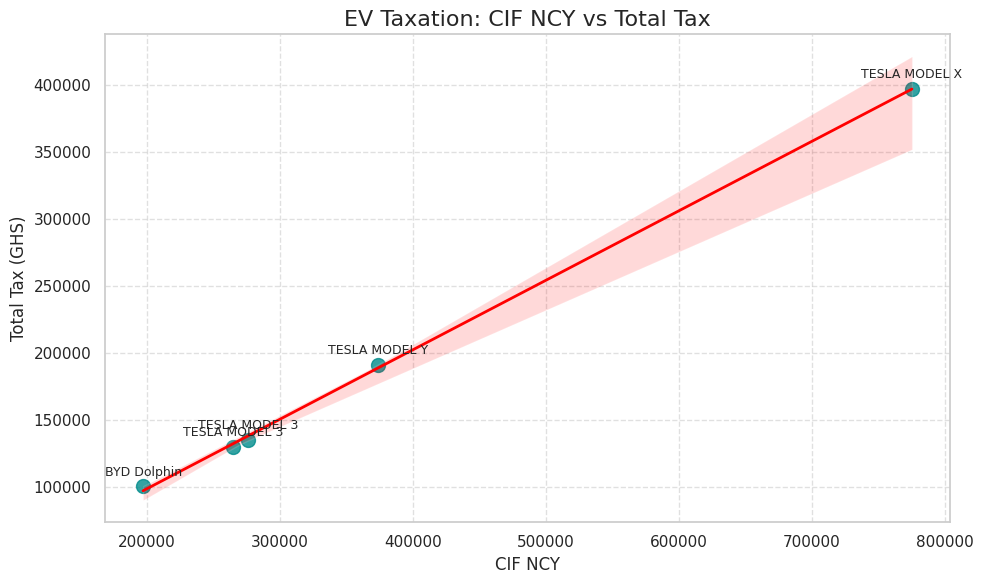

Correlation between CIF NCY and Total Tax for EVs: 0.9997


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualize CIF NCY vs Total Tax for EVs
plt.figure(figsize=(10, 6))
sns.regplot(data=ev_df, x='CIF NCY', y='Total Tax',
            scatter_kws={'s': 100, 'color': 'darkcyan', 'alpha': 0.8},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('EV Taxation: CIF NCY vs Total Tax', fontsize=16)
plt.xlabel('CIF NCY', fontsize=12)
plt.ylabel('Total Tax (GHS)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Add labels to the points so we know which car is which
for i in range(len(ev_df)):
    plt.text(ev_df['CIF NCY'].iloc[i], ev_df['Total Tax'].iloc[i] + 8000,
             f"{ev_df['Make'].iloc[i]} {ev_df['Model'].iloc[i]}",
             fontsize=9, ha='center')

plt.tight_layout()
plt.show()

# Calculate Correlation
ev_corr = ev_df[['CIF NCY', 'Total Tax']].corr().iloc[0, 1]
print(f"Correlation between CIF NCY and Total Tax for EVs: {ev_corr:.4f}")

In [57]:
from sklearn.linear_model import LinearRegression

# 2. Reverse Engineer the EV specific formula
X_ev = ev_df[['CIF NCY']]
y_ev = ev_df['Total Tax']

ev_model = LinearRegression()
ev_model.fit(X_ev, y_ev)

ev_cif_weight = ev_model.coef_[0]
ev_intercept = ev_model.intercept_

print("="*50)
print("REVERSE ENGINEERED EV TAX FORMULA")
print("="*50)
print(f"EV Total Tax = ({ev_cif_weight:.4f} * CIF NCY) {ev_intercept:+.4f}\n")

print("=== Multiplier Comparison ===")
print(f"Standard ICE Multiplier: ~0.4692  (approx. 47% of CIF)")
print(f"Electric Vehicle Multiplier:  ~{ev_cif_weight:.4f}  (approx. {ev_cif_weight*100:.1f}% of CIF)")

# 3. Test the new EV formula strictly on the BYD Dolphin
byd_cif = 197283.40
actual_byd = 100390.79
predicted_byd_ev = (ev_cif_weight * byd_cif) + ev_intercept

print("\n=== Re-Testing the BYD Dolphin with the EV Formula ===")
print(f"Actual Tax (from PDF): {actual_byd:,.2f} GHS")
print(f"EV Formula Prediction: {predicted_byd_ev:,.2f} GHS")
print(f"Difference:            {predicted_byd_ev - actual_byd:,.2f} GHS")
print("\nThis should be much closer than the Unified ICE model (-23,000 GHS error).")

REVERSE ENGINEERED EV TAX FORMULA
EV Total Tax = (0.5188 * CIF NCY) -5150.7013

=== Multiplier Comparison ===
Standard ICE Multiplier: ~0.4692  (approx. 47% of CIF)
Electric Vehicle Multiplier:  ~0.5188  (approx. 51.9% of CIF)

=== Re-Testing the BYD Dolphin with the EV Formula ===
Actual Tax (from PDF): 100,390.79 GHS
EV Formula Prediction: 97,196.40 GHS
Difference:            -3,194.39 GHS

This should be much closer than the Unified ICE model (-23,000 GHS error).


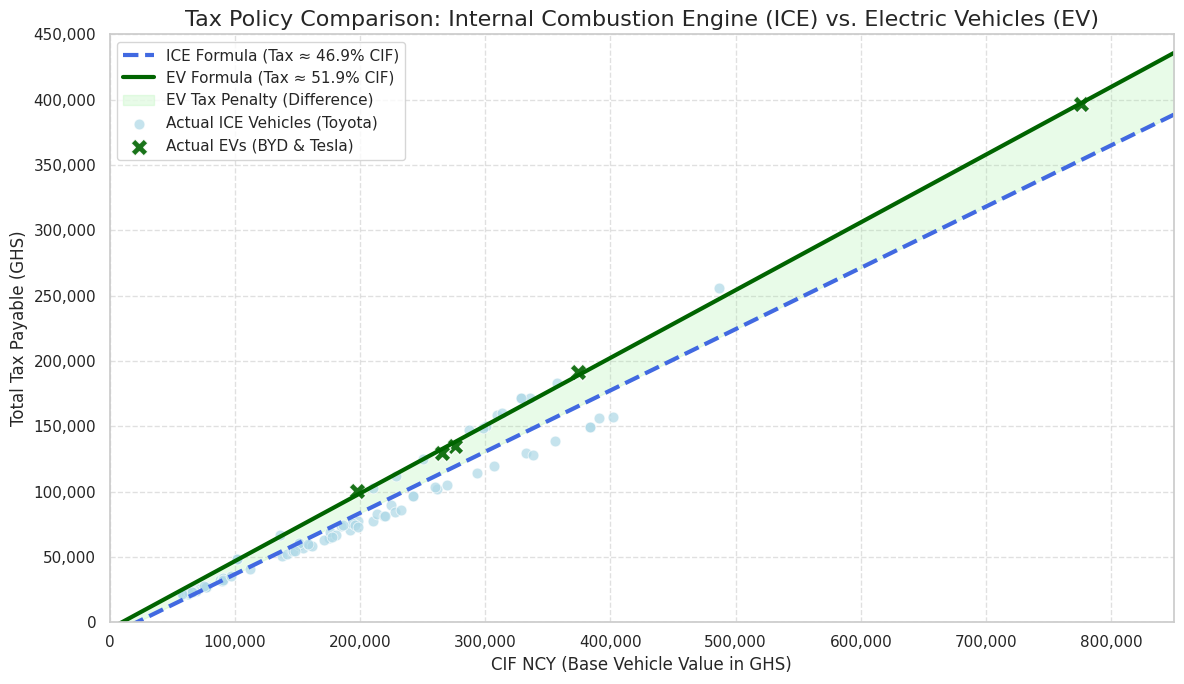

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Create a range of CIF NCY values from 0 to 850,000 for the trend lines
x_vals = np.linspace(0, 850000, 100)

# Calculate predicted taxes using our reverse-engineered formulas
y_ice = (cif_weight * x_vals) + intercept
y_ev = (ev_cif_weight * x_vals) + ev_intercept

plt.figure(figsize=(12, 7))

# Plot the formula lines
plt.plot(x_vals, y_ice, color='royalblue', linestyle='--', linewidth=3,
         label=f'ICE Formula (Tax ≈ {cif_weight*100:.1f}% CIF)')
plt.plot(x_vals, y_ev, color='darkgreen', linestyle='-', linewidth=3,
         label=f'EV Formula (Tax ≈ {ev_cif_weight*100:.1f}% CIF)')

# Highlight the widening gap
plt.fill_between(x_vals, y_ice, y_ev, color='lightgreen', alpha=0.2, label='EV Tax Penalty (Difference)')

# Scatter the actual data points for context
# ICE (Toyota Camry dataset as representative ICE)
sns.scatterplot(data=df_new, x='CIF NCY', y='Total Tax', color='lightblue',
                s=60, alpha=0.7, label='Actual ICE Vehicles (Toyota)')

# EV (BYD & Tesla)
sns.scatterplot(data=ev_df, x='CIF NCY', y='Total Tax', color='darkgreen',
                s=150, alpha=0.9, marker='X', label='Actual EVs (BYD & Tesla)')

plt.title('Tax Policy Comparison: Internal Combustion Engine (ICE) vs. Electric Vehicles (EV)', fontsize=16)
plt.xlabel('CIF NCY (Base Vehicle Value in GHS)', fontsize=12)
plt.ylabel('Total Tax Payable (GHS)', fontsize=12)

# Set limits to focus on the relevant range
plt.xlim(0, 850000)
plt.ylim(0, 450000)

# Format axes with commas for readability
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))

plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [59]:
def calculate_tax_difference(cif_value):
    """
    Calculates the exact tax difference between ICE and EV for a given CIF.
    """
    # Calculate taxes using the reverse-engineered formulas
    ice_tax = (cif_weight * cif_value) + intercept
    ev_tax = (ev_cif_weight * cif_value) + ev_intercept

    # Prevent negative taxes for extremely low CIF values (due to the intercept)
    ice_tax = max(0, ice_tax)
    ev_tax = max(0, ev_tax)

    difference = ev_tax - ice_tax

    print(f"=== Tax Comparison for CIF NCY: {cif_value:,.2f} GHS ===")
    print(f"Estimated ICE Tax (≈ {cif_weight*100:.1f}%): {ice_tax:,.2f} GHS")
    print(f"Estimated EV Tax  (≈ {ev_cif_weight*100:.1f}%): {ev_tax:,.2f} GHS")
    print("-" * 50)
    if difference > 0:
        print(f"EV Tax Penalty (Extra Cost):   +{difference:,.2f} GHS")
    elif difference < 0:
        print(f"EV Tax Savings (Discount):     {difference:,.2f} GHS")
    else:
        print(f"Difference:                      {difference:,.2f} GHS")
    print("=" * 50 + "\n")

# Let's show a couple of examples first
calculate_tax_difference(150000)
calculate_tax_difference(300000)

# Request user input
user_input = input("Enter a custom CIF NCY value to calculate the exact tax difference: ")

try:
    clean_cif_value = float(user_input.replace(',', ''))
    print("\n")
    calculate_tax_difference(clean_cif_value)
except ValueError:
    print("\nNo valid input provided. Run the cell again to enter a custom value.")

=== Tax Comparison for CIF NCY: 150,000.00 GHS ===
Estimated ICE Tax (≈ 46.9%): 60,170.46 GHS
Estimated EV Tax  (≈ 51.9%): 72,666.62 GHS
--------------------------------------------------
EV Tax Penalty (Extra Cost):   +12,496.16 GHS

=== Tax Comparison for CIF NCY: 300,000.00 GHS ===
Estimated ICE Tax (≈ 46.9%): 130,544.50 GHS
Estimated EV Tax  (≈ 51.9%): 150,483.93 GHS
--------------------------------------------------
EV Tax Penalty (Extra Cost):   +19,939.44 GHS

Enter a custom CIF NCY value to calculate the exact tax difference: 11000


=== Tax Comparison for CIF NCY: 11,000.00 GHS ===
Estimated ICE Tax (≈ 46.9%): 0.00 GHS
Estimated EV Tax  (≈ 51.9%): 555.90 GHS
--------------------------------------------------
EV Tax Penalty (Extra Cost):   +555.90 GHS



In [60]:
# Install xlsxwriter to generate advanced Excel files
!pip install -q xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 2.8 MB/s eta 0:00:00


In [62]:
import xlsxwriter
from google.colab import files

file_name = 'Vehicle_Tax_ICUMS_Receipt_Style.xlsx'
workbook = xlsxwriter.Workbook(file_name)
worksheet = workbook.add_worksheet('Duty Payable Report')

# --- Formats ---
title_format = workbook.add_format({'bold': True, 'font_size': 14, 'font_name': 'Arial'})
header_format = workbook.add_format({'bold': True, 'font_size': 10, 'font_name': 'Arial', 'bottom': 1})
cell_format = workbook.add_format({'font_size': 10, 'font_name': 'Arial'})
num_format = workbook.add_format({'font_size': 10, 'font_name': 'Arial', 'num_format': '#,##0.00'})
pct_format = workbook.add_format({'font_size': 10, 'font_name': 'Arial', 'num_format': '0.00'})
total_format = workbook.add_format({'bold': True, 'font_size': 11, 'font_name': 'Arial', 'top': 1, 'bottom': 4, 'num_format': '#,##0.00'})
disclaimer_format = workbook.add_format({'font_size': 8, 'font_name': 'Arial', 'italic': True, 'text_wrap': True})

# --- Column Widths ---
worksheet.set_column('A:A', 5)
worksheet.set_column('B:B', 35)
worksheet.set_column('C:C', 18)
worksheet.set_column('D:D', 10)
worksheet.set_column('E:E', 18)

# --- Vehicle Info Header ---
worksheet.write('A1', 'ICUMS Style Duty-Payable Report', title_format)
worksheet.write('A3', 'Vehicle Details', header_format)

# Inputs
worksheet.write('A4', 'Vehicle:', cell_format)
worksheet.write('B4', '2024 BYD Dolphin Hatchback 4D', cell_format)
worksheet.write('A5', 'Type:', cell_format)
worksheet.write('B5', 'Normal Electric', cell_format)

worksheet.write('D4', 'CIF (USD):', cell_format)
worksheet.write_number('E4', 17488.73, num_format) # Estimated from earlier CIF/FX
worksheet.write('D5', 'FX Rate:', cell_format)
worksheet.write_number('E5', 11.2806, num_format)

worksheet.write('D6', 'CIF (GHS):', cell_format)
worksheet.write_formula('E6', '=E4*E5', num_format)

# --- Taxes & Duty Payable Table ---
worksheet.write('A8', 'Taxes & Duty Payable', title_format)

headers = ['#', 'Descriptor', 'Base Amt', 'Rate', 'Payable']
for col_num, header in enumerate(headers):
    worksheet.write(9, col_num, header, header_format)

# We will reconstruct the PDF lines.
# In ICUMS, Base Amt is usually the CIF (GHS) value in E6, except for VAT which compounds.
line_items = [
    ('01', 'Import Duty', '=E6', 0.20, '=C11*D11'),
    ('02', 'Import VAT', '=(E6+E11)', 0.15, '=C12*D12'), # simplified VAT base
    ('05', 'Processing Fee', '=E6', 0.00, '=C13*D13'),
    ('06', 'ECOWAS Levy', '=E6', 0.01, '=C14*D14'),
    ('16', 'Vehicle Certification', 0.50, 1.00, '=C15*D15'),
    ('31', 'Vehicle Examination Fee', '=E6', 0.01, '=C16*D16'),
    ('32', 'Network Charge', '=E6*0.95', 0.00, '756.75'), # Hardcoded approximation from PDF
    ('33', 'Network Charge VAT', 783.24, 0.15, '=C18*D18'),
    ('45', 'Ghana Shippers Authority SNF Fee', 9.00, 1.00, '=C19*D19'),
    ('47', 'Import NHIL', 9.00, 1.00, '=C20*D20'),
    ('78', 'Special Import Levy (2%)', '=E6', 0.02, '=C21*D21'),
    ('87', 'Ghana Export-Import Bank (EXIM) Levy', '=E6', 0.01, '=C22*D22'),
    ('88', 'Ghana Education Trust (GET) Fund', '=(E6+E11)', 0.03, '=C23*D23'),
    ('98', 'African Union Import Levy', '=E6', 0.002, '=C24*D24') # usually 0.2%
]

row = 10
for item in line_items:
    worksheet.write(row, 0, item[0], cell_format)
    worksheet.write(row, 1, item[1], cell_format)

    # Base Amt
    if isinstance(item[2], str) and item[2].startswith('='):
        worksheet.write_formula(row, 2, item[2], num_format)
    else:
        worksheet.write_number(row, 2, item[2], num_format)

    # Rate
    worksheet.write_number(row, 3, item[3], pct_format)

    # Payable
    if isinstance(item[4], str) and item[4].startswith('='):
        worksheet.write_formula(row, 4, item[4], num_format)
    else:
        worksheet.write_number(row, 4, float(item[4]), num_format)

    row += 1

# Total Row
worksheet.write(row+1, 1, 'Total Payable (GHS)', title_format)
worksheet.write_formula(row+1, 4, f'=SUM(E11:E{row})', total_format)

# Disclaimer
worksheet.merge_range(row+3, 0, row+4, 4, 'Disclaimer: This is a dynamically generated layout reflecting the ICUMS Customs computation structure. Adjust CIF and FX rates to see simulated base and payable amounts recalculate.', disclaimer_format)

workbook.close()

print(f"Successfully generated '{file_name}'. Initiating download...")
files.download(file_name)


Successfully generated 'Vehicle_Tax_ICUMS_Receipt_Style.xlsx'. Initiating download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>